In [52]:
# Cell 01 — Imports and connection
import os
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import psycopg2
conn = psycopg2.connect(
    host='127.0.0.1', port=5455, dbname='postgres',
    user='postgres', password='postgres'
)
cur = conn.cursor()
print("Connected.")

Connected.


In [53]:
# Cell 02 — Schema introspection: int_game_environment
cur.execute("""
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'int'
    AND table_name = 'int_game_environment'
    ORDER BY ordinal_position
""")
print("int_game_environment:")
for row in cur.fetchall():
    print(" ", row)

int_game_environment:
  ('game_id', 'bigint')
  ('season', 'integer')
  ('week', 'integer')
  ('home_team', 'text')
  ('away_team', 'text')
  ('venue_id', 'bigint')
  ('is_dome', 'boolean')
  ('venue_elevation_ft', 'double precision')
  ('away_home_elevation_ft', 'double precision')
  ('away_elevation_delta_ft', 'double precision')
  ('away_elevation_ascent_ft', 'double precision')
  ('away_travel_distance_mi', 'numeric')
  ('away_tz_delta_hrs', 'integer')
  ('temperature_f', 'numeric')
  ('wind_speed_mph', 'numeric')
  ('wind_gusts_mph', 'numeric')
  ('precipitation_inches', 'numeric')
  ('humidity_pct', 'smallint')
  ('is_high_wind', 'boolean')
  ('is_precipitation', 'boolean')
  ('is_dome_adjusted_weather', 'boolean')


In [54]:
# Cell 03 — Schema introspection: int_game_team_features
cur.execute("""
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'int'
    AND table_name = 'int_game_team_features'
    ORDER BY ordinal_position
""")
print("int_game_team_features:")
for row in cur.fetchall():
    print(" ", row)

int_game_team_features:
  ('game_id', 'bigint')
  ('season', 'integer')
  ('week', 'integer')
  ('game_date', 'date')
  ('team_name', 'text')
  ('opponent', 'text')
  ('points_scored', 'integer')
  ('points_allowed', 'integer')
  ('win', 'integer')
  ('off_epa_per_play', 'numeric')
  ('def_epa_per_play_allowed', 'numeric')
  ('close_game_epa_per_play', 'numeric')
  ('close_game_play_count', 'bigint')
  ('close_game_def_epa_per_play', 'numeric')
  ('close_game_def_play_count', 'bigint')
  ('game_script', 'text')
  ('game_script_avg_margin', 'numeric')
  ('last3_off_epa_avg', 'numeric')
  ('last3_win_pct', 'numeric')
  ('last3_points_scored_avg', 'numeric')
  ('last3_def_epa_avg', 'numeric')
  ('last3_points_allowed_avg', 'numeric')
  ('days_since_last_game', 'integer')
  ('opp_sp_rating_at_game_time', 'numeric')
  ('pregame_elo', 'numeric')
  ('opponent_pregame_elo', 'numeric')
  ('postgame_elo', 'numeric')
  ('excitement_index', 'numeric')


In [55]:
# Cell 04 — Load all data
cur.execute("""
    SELECT
        g.game_id,
        g.season,
        g.week,
        g.team_name,
        g.opponent,
        g.points_scored,
        g.points_allowed,
        g.close_game_epa_per_play,
        g.close_game_def_epa_per_play,
        g.opp_sp_rating_at_game_time,
        c.conference,
        c2.conference            AS opp_conference,
        s.sp_rating              AS team_sp_rating,
        e.home_team,
        e.away_team,
        e.is_dome,
        e.is_dome_adjusted_weather,
        e.venue_elevation_ft,
        e.away_home_elevation_ft,
        e.away_elevation_delta_ft,
        e.away_elevation_ascent_ft,
        e.away_travel_distance_mi,
        e.away_tz_delta_hrs,
        e.temperature_f,
        e.wind_speed_mph,
        e.wind_gusts_mph,
        e.precipitation_inches,
        e.humidity_pct,
        e.is_high_wind,
        e.is_precipitation
    FROM int.int_game_team_features g
    JOIN int.int_team_season_context c
        ON g.team_name = c.team_name AND g.season = c.season
    JOIN int.int_team_season_context c2
        ON g.opponent = c2.team_name AND g.season = c2.season
    JOIN int.int_team_season_features s
        ON g.team_name = s.team_name AND g.season = s.season
    JOIN int.int_game_environment e
        ON g.game_id = e.game_id
       AND g.team_name IN (e.home_team, e.away_team)
    WHERE g.points_scored IS NOT NULL
      AND g.points_allowed IS NOT NULL
      AND g.season IN (2022, 2023, 2024)
      AND c.conference IN (
          'SEC','Big Ten','Big 12','ACC','Pac-12',
          'Mountain West','American Athletic','Sun Belt',
          'Mid-American','Conference USA'
      )
""")
rows = cur.fetchall()
cols = [d[0] for d in cur.description]
df = pd.DataFrame(rows, columns=cols)

numeric_cols = [
    "points_scored","points_allowed","close_game_epa_per_play",
    "close_game_def_epa_per_play","opp_sp_rating_at_game_time","team_sp_rating",
    "venue_elevation_ft","away_home_elevation_ft","away_elevation_delta_ft",
    "away_elevation_ascent_ft","away_travel_distance_mi","away_tz_delta_hrs",
    "temperature_f","wind_speed_mph","wind_gusts_mph","precipitation_inches","humidity_pct"
]
df[numeric_cols] = df[numeric_cols].astype(float)

bool_cols = ["is_dome","is_dome_adjusted_weather","is_high_wind","is_precipitation"]
for col in bool_cols:
    df[col] = df[col].map(lambda x: 1 if x is True else (0 if x is False else np.nan)).astype(float)

df["point_differential"] = df["points_scored"] - df["points_allowed"]
df["total_points"]       = df["points_scored"] + df["points_allowed"]
df["is_away_team"]       = (df["team_name"] == df["away_team"]).astype(float)
df["is_home_team"]       = (df["team_name"] == df["home_team"]).astype(float)

# Integrity assertion — FBS Independents must not appear
assert "FBS Independents" not in df["conference"].unique(), \
    "FBS Independents found in df — check WHERE clause"

print(f"Raw rows loaded: {len(df):,}")
print(f"Seasons        : {sorted(df['season'].unique())}")
print(f"Conferences    : {sorted(df['conference'].unique())}")

Raw rows loaded: 4,320
Seasons        : [2022, 2023, 2024]
Conferences    : ['ACC', 'American Athletic', 'Big 12', 'Big Ten', 'Conference USA', 'Mid-American', 'Mountain West', 'Pac-12', 'SEC', 'Sun Belt']


In [56]:
# Cell 05 — Derive wind_chill and heat_index
# Wind chill: NWS formula, meaningful when temp < 50°F AND wind > 3 mph
# Heat index: Rothfusz regression, meaningful when temp > 80°F AND humidity > 40%

def compute_wind_chill(row):
    T = row["temperature_f"]
    W = row["wind_speed_mph"]
    if row["is_dome"] == 1:
        return np.nan
    if pd.isna(T) or pd.isna(W):
        return np.nan
    if T >= 50 or W <= 3:
        return T  # conditions not met, wind chill = temp
    return (35.74 + 0.6215*T - 35.75*(W**0.16) + 0.4275*T*(W**0.16))

def compute_heat_index(row):
    T = row["temperature_f"]
    H = row["humidity_pct"]
    if row["is_dome"] == 1:
        return np.nan
    if pd.isna(T) or pd.isna(H):
        return np.nan
    if T <= 80 or H <= 40:
        return T  # conditions not met, heat index = temp
    return (-42.379 + 2.04901523*T + 10.14333127*H
            - 0.22475541*T*H - 0.00683783*T*T
            - 0.05481717*H*H + 0.00122874*T*T*H
            + 0.00085282*T*H*H - 0.00000199*T*T*H*H)

df["wind_chill"]  = df.apply(compute_wind_chill, axis=1)
df["heat_index"]  = df.apply(compute_heat_index, axis=1)

print("Derived columns computed.")
print(f"\nWind chill: n={df['wind_chill'].notna().sum():,}  "
      f"mean={df['wind_chill'].mean():.1f}  "
      f"min={df['wind_chill'].min():.1f}  "
      f"max={df['wind_chill'].max():.1f}")
print(f"Heat index: n={df['heat_index'].notna().sum():,}  "
      f"mean={df['heat_index'].mean():.1f}  "
      f"min={df['heat_index'].min():.1f}  "
      f"max={df['heat_index'].max():.1f}")
# How many games where wind chill is actually triggered (< 50°F AND wind > 3)
wc_triggered = df[(df["temperature_f"] < 50) & (df["wind_speed_mph"] > 3) & (df["is_dome"] == 0)]
hi_triggered = df[(df["temperature_f"] > 80) & (df["humidity_pct"] > 40) & (df["is_dome"] == 0)]
print(f"\nWind chill triggered (temp<50, wind>3, non-dome): {len(wc_triggered):,}")
print(f"Heat index triggered (temp>80, humidity>40, non-dome): {len(hi_triggered):,}")

Derived columns computed.

Wind chill: n=4,149  mean=65.7  min=2.3  max=107.9
Heat index: n=4,149  mean=66.7  min=17.0  max=107.9

Wind chill triggered (temp<50, wind>3, non-dome): 520
Heat index triggered (temp>80, humidity>40, non-dome): 481


In [57]:
# Cell 06 — Conference game filter + assign_tier
P4_CONFERENCES = {"ACC", "Big 12", "Big Ten", "SEC"}

def assign_tier(row):
    if row["team_name"] == "Notre Dame":
        return "P4"
    if row["team_name"] == "UConn":
        return "G5"
    if row["conference"] in P4_CONFERENCES:
        return "P4"
    return "G5"

df["tier"] = df.apply(assign_tier, axis=1)

# True conference games
gdf_conf = df[
    (df["conference"] == df["opp_conference"]) &
    (df["conference"] != "FBS Independents")
].copy()

# Notre Dame ACC schedule — pools with ACC for environmental analysis
nd_conf = df[
    (df["team_name"] == "Notre Dame") &
    (df["opp_conference"] == "ACC")
].copy()
nd_conf["conference"] = "ACC"

gdf_conf = pd.concat([gdf_conf, nd_conf], ignore_index=True)
gdf_conf = gdf_conf.drop_duplicates(subset=["game_id","team_name"])
gdf_conf = gdf_conf.sort_values(["team_name","season","week"])
gdf_conf["conf_game_num"] = gdf_conf.groupby(
    ["team_name","season"]
).cumcount() + 1

# Away-team-only view for travel and elevation
away_only = gdf_conf[gdf_conf["is_away_team"] == 1].copy()

print(f"Conference game rows   : {len(gdf_conf):,}")
print(f"Away team rows         : {len(away_only):,}")
print(f"Dome games             : {gdf_conf['is_dome'].sum():,.0f}")
print(f"Non-dome games         : {(gdf_conf['is_dome']==0).sum():,}")

print(f"\nNull audit (conference games):")
audit_cols = [
    "venue_elevation_ft","away_elevation_delta_ft","away_travel_distance_mi",
    "away_tz_delta_hrs","temperature_f","wind_speed_mph","humidity_pct",
    "wind_chill","heat_index","precipitation_inches","is_high_wind","is_precipitation"
]
for col in audit_cols:
    n = gdf_conf[col].isna().sum()
    pct = n / len(gdf_conf) * 100
    print(f"  {col:35s} {n:,} ({pct:.1f}%)")

print(f"\nKey counts:")
print(f"  High wind games (non-dome)    : {gdf_conf[(gdf_conf['is_high_wind']==1)&(gdf_conf['is_dome']==0)]['game_id'].nunique():,}")
print(f"  Precipitation games (non-dome): {gdf_conf[(gdf_conf['is_precipitation']==1)&(gdf_conf['is_dome']==0)]['game_id'].nunique():,}")

Conference game rows   : 3,218
Away team rows         : 1,609
Dome games             : 114
Non-dome games         : 3,104

Null audit (conference games):
  venue_elevation_ft                  0 (0.0%)
  away_elevation_delta_ft             0 (0.0%)
  away_travel_distance_mi             40 (1.2%)
  away_tz_delta_hrs                   0 (0.0%)
  temperature_f                       12 (0.4%)
  wind_speed_mph                      12 (0.4%)
  humidity_pct                        12 (0.4%)
  wind_chill                          126 (3.9%)
  heat_index                          126 (3.9%)
  precipitation_inches                12 (0.4%)
  is_high_wind                        12 (0.4%)
  is_precipitation                    12 (0.4%)

Key counts:
  High wind games (non-dome)    : 183
  Precipitation games (non-dome): 22


In [58]:
# Cell 07 — Distribution summary
print("Distribution summary for key environmental features:\n")

dist_cols = [
    ("venue_elevation_ft",     "all games"),
    ("away_elevation_delta_ft","away team rows"),
    ("away_travel_distance_mi","away team rows"),
    ("away_tz_delta_hrs",      "away team rows"),
    ("temperature_f",          "non-dome"),
    ("wind_speed_mph",         "non-dome"),
    ("humidity_pct",           "non-dome"),
    ("wind_chill",             "non-dome, wc triggered"),
    ("heat_index",             "non-dome, hi triggered"),
]

non_dome = gdf_conf[gdf_conf["is_dome"] == 0].copy()

for col, pop in dist_cols:
    if pop == "away team rows":
        sub = away_only[col].dropna()
    elif pop == "non-dome":
        sub = non_dome[col].dropna()
    elif pop == "non-dome, wc triggered":
        sub = non_dome[(non_dome["temperature_f"] < 50) &
                       (non_dome["wind_speed_mph"] > 3)][col].dropna()
    elif pop == "non-dome, hi triggered":
        sub = non_dome[(non_dome["temperature_f"] > 80) &
                       (non_dome["humidity_pct"] > 40)][col].dropna()
    else:
        sub = gdf_conf[col].dropna()

    print(f"  {col:35s} [{pop}]")
    print(f"    n={len(sub):,}  mean={sub.mean():.2f}  median={sub.median():.2f}  "
          f"SD={sub.std():.2f}  min={sub.min():.2f}  max={sub.max():.2f}")
    print(f"    p25={sub.quantile(0.25):.2f}  p75={sub.quantile(0.75):.2f}  "
          f"p90={sub.quantile(0.90):.2f}  p95={sub.quantile(0.95):.2f}")
    print()

Distribution summary for key environmental features:

  venue_elevation_ft                  [all games]
    n=3,218  mean=1004.26  median=629.90  SD=1361.55  min=0.00  max=7217.80
    p25=246.10  p75=938.30  p90=2710.00  p95=4675.20

  away_elevation_delta_ft             [away team rows]
    n=1,609  mean=0.07  median=0.00  SD=1606.16  min=-7194.80  max=7194.80
    p25=-403.50  p75=393.70  p90=1130.60  p95=2976.36

  away_travel_distance_mi             [away team rows]
    n=1,589  mean=563.65  median=430.10  SD=510.29  min=8.50  max=4091.70
    p25=238.70  p75=733.60  p90=1090.82  p95=1505.00

  away_tz_delta_hrs                   [away team rows]
    n=1,609  mean=0.00  median=0.00  SD=0.81  min=-3.00  max=3.00
    p25=0.00  p75=0.00  p90=1.00  p95=1.00

  temperature_f                       [non-dome]
    n=3,092  mean=63.06  median=64.35  SD=14.81  min=17.00  max=105.50
    p25=53.00  p75=74.00  p90=81.30  p95=85.20

  wind_speed_mph                      [non-dome]
    n=3,092  mea

In [59]:
# Cell 08 — Helpers (defined once, never redefined)
EPA_ANCHOR = ["close_game_epa_per_play", "close_game_def_epa_per_play"]
THRESHOLD  = 0.10

def partial_corr(df_, x_col, y_col, control_cols):
    sub = df_[[x_col, y_col] + control_cols].dropna()
    n = len(sub)
    if n < 30:
        return np.nan, np.nan, n
    def resid(target, predictors):
        X = sub[predictors].values
        y = sub[target].values
        return y - LinearRegression().fit(X, y).predict(X)
    r, p = stats.pearsonr(resid(x_col, control_cols), resid(y_col, control_cols))
    return r, p, n

def ols_stats(x_cols, y_col, df_, label=""):
    sub = df_[[y_col] + x_cols].dropna()
    X = sub[x_cols].values
    y = sub[y_col].values
    reg = LinearRegression().fit(X, y)
    yhat = reg.predict(X)
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res/ss_tot
    n, k = len(y), len(x_cols)
    adj_r2 = 1 - (1-r2)*(n-1)/(n-k-1)
    resid_sd = np.std(y-yhat, ddof=k+1)
    print(f"  {label:55s} R²={r2:.4f}  adj R²={adj_r2:.4f}  resid_SD={resid_sd:.4f}  n={n:,}")
    return r2, adj_r2, resid_sd

def threshold_partial_corr(df_, feat, target, controls, thresholds, direction="above"):
    """Run partial r within threshold populations and print results."""
    print(f"\n  {feat} → {target} | threshold analysis ({direction}):")
    print(f"  {'Threshold':20s} {'n':>6} {'partial_r':>10} {'p':>10} {'signal':>8}")
    print(f"  {'-'*58}")
    results = {}
    for thresh in thresholds:
        if direction == "above":
            sub = df_[df_[feat] >= thresh]
        else:
            sub = df_[df_[feat] <= thresh]
        r, p, n = partial_corr(sub, feat, target, controls)
        signal = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
        r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
        print(f"  {f'>={thresh}' if direction=='above' else f'<={thresh}':20s} "
              f"{n:>6,} {r_str:>10} {p:>10.4f} {signal:>8}")
        results[thresh] = {"r": r, "p": p, "n": n}
    return results

def bootstrap_r(x, y, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    r_obs, _ = stats.pearsonr(x, y)
    boots = [stats.pearsonr(x[rng.integers(0,len(x),len(x))],
                            y[rng.integers(0,len(x),len(x))])[0]
             for _ in range(n_boot)]
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return r_obs, lo, hi, len(x)

print(f"Helpers defined. EPA_ANCHOR={EPA_ANCHOR}  THRESHOLD={THRESHOLD}")

Helpers defined. EPA_ANCHOR=['close_game_epa_per_play', 'close_game_def_epa_per_play']  THRESHOLD=0.1


In [60]:
# Cell 09 — Section 3: Elevation — distributions and population identification

print("=" * 70)
print("SECTION 3 — ELEVATION ANALYSIS")
print("=" * 70)

print(f"\nElevation distribution — all conference games:")
for col in ["venue_elevation_ft","away_elevation_delta_ft"]:
    sub = gdf_conf[col].dropna()
    print(f"  {col:35s} mean={sub.mean():.0f}  SD={sub.std():.0f}  "
          f"max={sub.max():.0f}  n={len(sub):,}")

print(f"\nHigh-elevation venue game counts (venue_elevation_ft):")
for thresh in [1000, 2000, 3000, 4000, 5000]:
    n = (gdf_conf["venue_elevation_ft"] >= thresh).sum()
    print(f"  >= {thresh:5d} ft : {n:,} rows")

print(f"\nLarge elevation delta game counts (away_elevation_delta_ft, away team only):")
for thresh in [500, 1000, 1500, 2000, 3000, 5000]:
    n = (away_only["away_elevation_delta_ft"] >= thresh).sum()
    print(f"  >= {thresh:5d} ft : {n:,} away-team rows")

# High-elevation conferences
print(f"\nConferences with high-elevation venues (mean venue_elevation_ft):")
conf_elev = gdf_conf.groupby("conference")["venue_elevation_ft"].agg(["mean","max","count"])
conf_elev = conf_elev.sort_values("mean", ascending=False)
print(conf_elev.round(0).to_string())

SECTION 3 — ELEVATION ANALYSIS

Elevation distribution — all conference games:
  venue_elevation_ft                  mean=1004  SD=1362  max=7218  n=3,218
  away_elevation_delta_ft             mean=0  SD=1606  max=7195  n=3,218

High-elevation venue game counts (venue_elevation_ft):
  >=  1000 ft : 714 rows
  >=  2000 ft : 428 rows
  >=  3000 ft : 304 rows
  >=  4000 ft : 212 rows
  >=  5000 ft : 120 rows

Large elevation delta game counts (away_elevation_delta_ft, away team only):
  >=   500 ft : 342 away-team rows
  >=  1000 ft : 183 away-team rows
  >=  1500 ft : 146 away-team rows
  >=  2000 ft : 128 away-team rows
  >=  3000 ft : 81 away-team rows
  >=  5000 ft : 13 away-team rows

Conferences with high-elevation venues (mean venue_elevation_ft):
                     mean     max  count
conference                              
Mountain West      3197.0  7218.0    282
Pac-12             1527.0  5368.0    222
Big 12             1396.0  5368.0    370
Conference USA     1043.0  3983.0

In [61]:
# Cell 10 — Section 3: Elevation — individual component partial r (away team only)

print("=== 3a: Elevation individual components — away team only ===\n")
print("Away team only: elevation delta affects the away team's performance")
print("Controls: EPA anchor pair\n")

print(f"{'Feature':35s} {'target':25s} {'partial_r':>10} {'p':>10} {'n':>8} {'signal':>8}")
print("-" * 90)
elev_component_results = {}
for feat in ["venue_elevation_ft","away_elevation_delta_ft","away_elevation_ascent_ft"]:
    for target in ["point_differential","total_points"]:
        r, p, n = partial_corr(away_only, feat, target, EPA_ANCHOR)
        signal = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
        r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
        print(f"  {feat:33s} {target:25s} {r_str:>10} {p:>10.4f} {n:>8,} {signal:>8}")
        elev_component_results[(feat, target)] = {"r": r, "p": p, "n": n}

=== 3a: Elevation individual components — away team only ===

Away team only: elevation delta affects the away team's performance
Controls: EPA anchor pair

Feature                             target                     partial_r          p        n   signal
------------------------------------------------------------------------------------------
  venue_elevation_ft                point_differential           -0.0298     0.2331    1,606        ✗
  venue_elevation_ft                total_points                 -0.0093     0.7105    1,606        ✗
  away_elevation_delta_ft           point_differential           -0.0152     0.5437    1,606        ✗
  away_elevation_delta_ft           total_points                  0.0132     0.5970    1,606        ✗
  away_elevation_ascent_ft          point_differential           -0.0296     0.2352    1,606        ✗
  away_elevation_ascent_ft          total_points                  0.0026     0.9176    1,606        ✗


In [62]:
# Cell 11 — Section 3: Elevation — threshold sweep

print("=== 3b: Elevation threshold sweep — away_elevation_delta_ft ===")
print("Does signal concentrate above specific elevation deltas?\n")

elev_threshold_results = {}
for target in ["point_differential","total_points"]:
    res = threshold_partial_corr(
        away_only, "away_elevation_delta_ft", target, EPA_ANCHOR,
        thresholds=[500, 1000, 1500, 2000, 3000, 5000],
        direction="above"
    )
    elev_threshold_results[target] = res

=== 3b: Elevation threshold sweep — away_elevation_delta_ft ===
Does signal concentrate above specific elevation deltas?


  away_elevation_delta_ft → point_differential | threshold analysis (above):
  Threshold                 n  partial_r          p   signal
  ----------------------------------------------------------
  >=500                   342     0.0134     0.8049        ✗
  >=1000                  183     0.1563     0.0347        ✓
  >=1500                  146     0.1243     0.1350        ✓
  >=2000                  128     0.1518     0.0872        ✓
  >=3000                   81     0.0914     0.4172        ✗
  >=5000                   13       nan         nan        ✗

  away_elevation_delta_ft → total_points | threshold analysis (above):
  Threshold                 n  partial_r          p   signal
  ----------------------------------------------------------
  >=500                   342    -0.1026     0.0581        ✓
  >=1000                  183    -0.0592     0.4258      

In [63]:
# Cell 12 — Section 3: Elevation — home team altitude advantage t-test
# Within high-elevation venues, does the home team outperform EPA expectations
# more than in sea-level venues? This tests whether elevation is a home
# advantage amplifier, not just an away team disadvantage.

print("=== 3c: Home team altitude advantage ===\n")
print("Do home teams at high elevation outperform EPA expectations")
print("more than home teams at sea level?\n")

home_only = gdf_conf[gdf_conf["is_home_team"] == 1].copy()

# Compute EPA residual for home team points_scored
sub_home = home_only[EPA_ANCHOR + ["points_scored","venue_elevation_ft"]].dropna()
X = sub_home[EPA_ANCHOR].values
y = sub_home["points_scored"].values
reg = LinearRegression().fit(X, y)
sub_home = sub_home.copy()
sub_home["epa_residual"] = y - reg.predict(X)

for thresh in [2000, 3000, 5000]:
    high_elev_home = sub_home[sub_home["venue_elevation_ft"] >= thresh]["epa_residual"]
    low_elev_home  = sub_home[sub_home["venue_elevation_ft"] <  thresh]["epa_residual"]
    if len(high_elev_home) < 10:
        print(f"  >= {thresh}ft: insufficient sample (n={len(high_elev_home)})")
        continue
    t, p = stats.ttest_ind(high_elev_home, low_elev_home)
    print(f"  Home EPA residual >= {thresh}ft: mean={high_elev_home.mean():+.2f} pts  "
          f"n={len(high_elev_home):,}")
    print(f"  Home EPA residual <  {thresh}ft: mean={low_elev_home.mean():+.2f} pts  "
          f"n={len(low_elev_home):,}")
    print(f"  t={t:.3f}  p={p:.4f}  "
          f"{'✓ significant altitude advantage' if p < 0.05 else '✗ not significant'}")
    print()

=== 3c: Home team altitude advantage ===

Do home teams at high elevation outperform EPA expectations
more than home teams at sea level?

  Home EPA residual >= 2000ft: mean=+0.51 pts  n=214
  Home EPA residual <  2000ft: mean=-0.08 pts  n=1,392
  t=1.022  p=0.3067  ✗ not significant

  Home EPA residual >= 3000ft: mean=+0.58 pts  n=152
  Home EPA residual <  3000ft: mean=-0.06 pts  n=1,454
  t=0.953  p=0.3408  ✗ not significant

  Home EPA residual >= 5000ft: mean=-0.68 pts  n=60
  Home EPA residual <  5000ft: mean=+0.03 pts  n=1,546
  t=-0.684  p=0.4942  ✗ not significant



In [64]:
# Cell 13 — Section 3: Elevation — YoY stability

print("=== 3d: Elevation YoY stability ===\n")
print("Elevation is structural — should be highly stable YoY.")
print("Benchmarks: off_epa r=0.423, SP+ r=0.761, threshold for anchor: r>=0.80\n")

# Team-season level: avg away_elevation_delta per team per season
elev_season = away_only.groupby(["team_name","season"]).agg(
    avg_elev_delta=("away_elevation_delta_ft","mean"),
    avg_venue_elev=("venue_elevation_ft","mean"),
).reset_index()
elev_n  = elev_season.copy()
elev_n1 = elev_season.copy()
elev_n1["season"] = elev_n1["season"] - 1
yoy_elev = elev_n.merge(elev_n1, on=["team_name","season"], suffixes=("_n","_n1"))

print(f"YoY pairs: {len(yoy_elev):,}")
elev_yoy_results = {}
for feat in ["avg_elev_delta","avg_venue_elev"]:
    r, lo, hi, n = bootstrap_r(
        yoy_elev[f"{feat}_n"].values,
        yoy_elev[f"{feat}_n1"].values
    )
    stable = "✓ YES" if r >= 0.80 else "✗ NO"
    print(f"  {feat:25s} r={r:.4f}  95% CI [{lo:.4f}, {hi:.4f}]  n={n:,}  {stable}")
    elev_yoy_results[feat] = {"r": r, "stable": r >= 0.80}

=== 3d: Elevation YoY stability ===

Elevation is structural — should be highly stable YoY.
Benchmarks: off_epa r=0.423, SP+ r=0.761, threshold for anchor: r>=0.80

YoY pairs: 252
  avg_elev_delta            r=0.8258  95% CI [-0.1241, 0.1212]  n=252  ✓ YES
  avg_venue_elev            r=0.6794  95% CI [-0.1126, 0.1310]  n=252  ✗ NO


In [65]:
# Cell 14 — Section 3: Elevation — Mountain West and Big 12 stratified

print("=== 3e: Elevation — Mountain West + Big 12 stratified ===\n")
print("Signal should concentrate in these conferences where elevation is meaningful\n")

mw_b12_away = away_only[away_only["conference"].isin(["Mountain West","Big 12"])].copy()
all_other_away = away_only[~away_only["conference"].isin(["Mountain West","Big 12"])].copy()

print(f"Mountain West + Big 12 away rows: {len(mw_b12_away):,}")
print(f"All other conferences away rows : {len(all_other_away):,}")

print(f"\n{'Population':35s} {'target':25s} {'partial_r':>10} {'p':>10} {'n':>8} {'signal':>8}")
print("-" * 95)
elev_conf_results = {}
for subset, label in [
    (mw_b12_away,   "Mountain West + Big 12"),
    (all_other_away,"All other conferences"),
    (away_only,     "Full away population"),
]:
    for target in ["point_differential","total_points"]:
        r, p, n = partial_corr(subset, "away_elevation_delta_ft", target, EPA_ANCHOR)
        signal = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
        r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
        print(f"  {label:33s} {target:25s} {r_str:>10} {p:>10.4f} {n:>8,} {signal:>8}")
        elev_conf_results[(label, target)] = {"r": r, "p": p, "n": n}

=== 3e: Elevation — Mountain West + Big 12 stratified ===

Signal should concentrate in these conferences where elevation is meaningful

Mountain West + Big 12 away rows: 326
All other conferences away rows : 1,283

Population                          target                     partial_r          p        n   signal
-----------------------------------------------------------------------------------------------
  Mountain West + Big 12            point_differential           -0.0034     0.9512      326        ✗
  Mountain West + Big 12            total_points                  0.0734     0.1865      326        ✗
  All other conferences             point_differential           -0.0251     0.3695    1,280        ✗
  All other conferences             total_points                 -0.0218     0.4362    1,280        ✗
  Full away population              point_differential           -0.0152     0.5437    1,606        ✗
  Full away population              total_points                  0.0132    

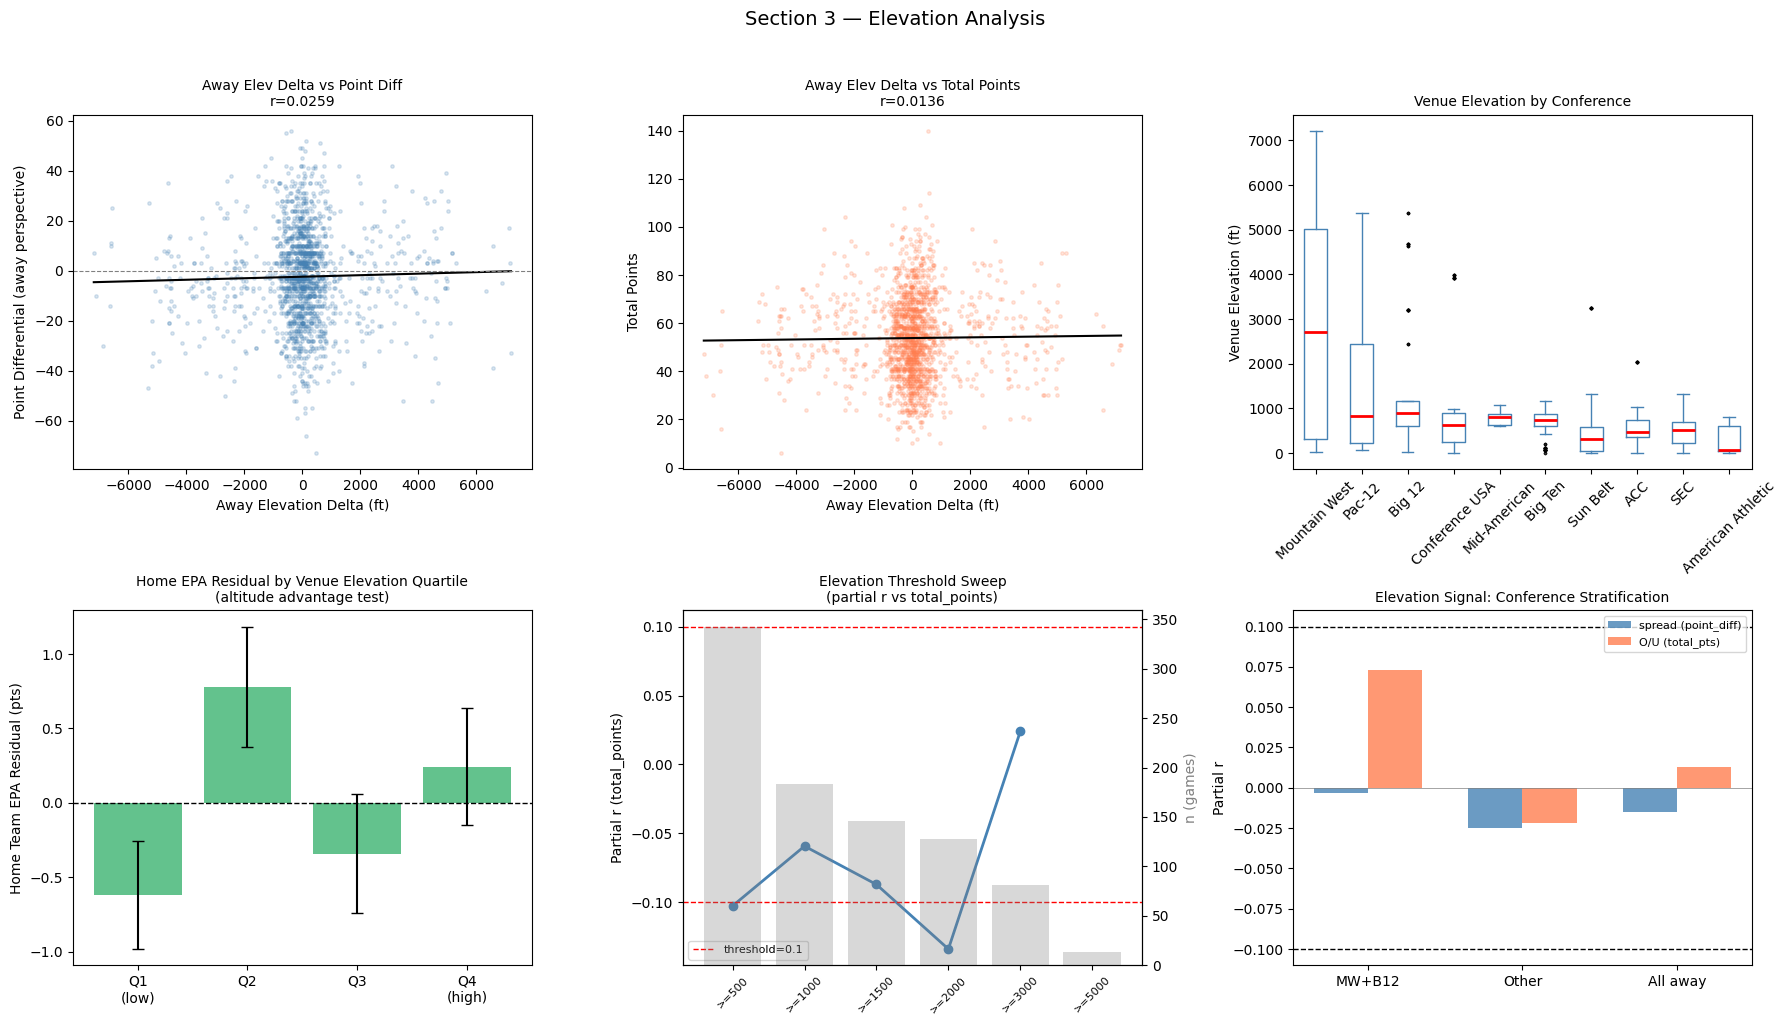

In [66]:
# Cell 15 — Section 3: Elevation visualization

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. away_elevation_delta vs point_differential (away only)
sub = away_only[["away_elevation_delta_ft","point_differential"]].dropna()
axes[0][0].scatter(sub["away_elevation_delta_ft"], sub["point_differential"],
                   alpha=0.2, s=6, color="steelblue")
m, b = np.polyfit(sub["away_elevation_delta_ft"], sub["point_differential"], 1)
xl = np.linspace(sub["away_elevation_delta_ft"].min(),
                 sub["away_elevation_delta_ft"].max(), 200)
axes[0][0].plot(xl, m*xl+b, color="black", lw=1.5)
r, _ = stats.pearsonr(sub["away_elevation_delta_ft"], sub["point_differential"])
axes[0][0].set_xlabel("Away Elevation Delta (ft)")
axes[0][0].set_ylabel("Point Differential (away perspective)")
axes[0][0].set_title(f"Away Elev Delta vs Point Diff\nr={r:.4f}", fontsize=10)
axes[0][0].axhline(0, color="gray", lw=0.8, ls="--")

# 2. away_elevation_delta vs total_points (away only)
sub = away_only[["away_elevation_delta_ft","total_points"]].dropna()
axes[0][1].scatter(sub["away_elevation_delta_ft"], sub["total_points"],
                   alpha=0.2, s=6, color="coral")
m, b = np.polyfit(sub["away_elevation_delta_ft"], sub["total_points"], 1)
xl = np.linspace(sub["away_elevation_delta_ft"].min(),
                 sub["away_elevation_delta_ft"].max(), 200)
axes[0][1].plot(xl, m*xl+b, color="black", lw=1.5)
r, _ = stats.pearsonr(sub["away_elevation_delta_ft"], sub["total_points"])
axes[0][1].set_xlabel("Away Elevation Delta (ft)")
axes[0][1].set_ylabel("Total Points")
axes[0][1].set_title(f"Away Elev Delta vs Total Points\nr={r:.4f}", fontsize=10)

# 3. Venue elevation distribution by conference
conf_order = gdf_conf.groupby("conference")["venue_elevation_ft"].mean().sort_values(ascending=False).index
data_by_conf = [gdf_conf[gdf_conf["conference"]==c]["venue_elevation_ft"].dropna().values
                for c in conf_order]
axes[0][2].boxplot(data_by_conf, labels=conf_order,
                   boxprops=dict(color="steelblue"),
                   medianprops=dict(color="red", lw=2),
                   whiskerprops=dict(color="steelblue"),
                   capprops=dict(color="steelblue"),
                   flierprops=dict(marker=".", alpha=0.3, ms=3))
axes[0][2].set_title("Venue Elevation by Conference", fontsize=10)
axes[0][2].set_ylabel("Venue Elevation (ft)")
axes[0][2].tick_params(axis="x", rotation=45)

# 4. Home EPA residual by elevation quartile
sub_home_q = sub_home.copy()
sub_home_q["elev_quartile"] = pd.qcut(
    sub_home_q["venue_elevation_ft"], q=4,
    labels=["Q1\n(low)","Q2","Q3","Q4\n(high)"]
)
grp = sub_home_q.groupby("elev_quartile")["epa_residual"].agg(["mean","std","count"])
x = np.arange(4)
axes[1][0].bar(x, grp["mean"], yerr=grp["std"]/np.sqrt(grp["count"]),
               color="mediumseagreen", alpha=0.8, capsize=4)
axes[1][0].axhline(0, color="black", lw=1, ls="--")
axes[1][0].set_xticks(x)
axes[1][0].set_xticklabels(["Q1\n(low)","Q2","Q3","Q4\n(high)"])
axes[1][0].set_ylabel("Home Team EPA Residual (pts)")
axes[1][0].set_title("Home EPA Residual by Venue Elevation Quartile\n(altitude advantage test)",
                     fontsize=10)

# 5. Threshold sweep plot — partial r vs total_points by elevation threshold
thresholds = [500, 1000, 1500, 2000, 3000, 5000]
r_vals = [elev_threshold_results["total_points"].get(t, {}).get("r", np.nan)
          for t in thresholds]
n_vals = [elev_threshold_results["total_points"].get(t, {}).get("n", 0)
          for t in thresholds]
ax5 = axes[1][1]
ax5_twin = ax5.twinx()
ax5.plot(range(len(thresholds)), r_vals, marker="o", color="steelblue", lw=2)
ax5_twin.bar(range(len(thresholds)), n_vals, alpha=0.3, color="gray")
ax5.axhline(THRESHOLD, color="red", lw=1, ls="--", label=f"threshold={THRESHOLD}")
ax5.axhline(-THRESHOLD, color="red", lw=1, ls="--")
ax5.set_xticks(range(len(thresholds)))
ax5.set_xticklabels([f">={t}" for t in thresholds], rotation=45, fontsize=8)
ax5.set_ylabel("Partial r (total_points)")
ax5_twin.set_ylabel("n (games)", color="gray")
ax5.set_title("Elevation Threshold Sweep\n(partial r vs total_points)", fontsize=10)
ax5.legend(fontsize=8)

# 6. MW + B12 vs all others
labels_plot = ["MW+B12","Other","All away"]
r_spread_vals = [elev_conf_results.get((l,"point_differential"),{}).get("r",np.nan)
                 for l in ["Mountain West + Big 12","All other conferences","Full away population"]]
r_ou_vals    = [elev_conf_results.get((l,"total_points"),{}).get("r",np.nan)
                for l in ["Mountain West + Big 12","All other conferences","Full away population"]]
x = np.arange(3)
w = 0.35
axes[1][2].bar(x-w/2, r_spread_vals, w, label="spread (point_diff)", color="steelblue", alpha=0.8)
axes[1][2].bar(x+w/2, r_ou_vals,    w, label="O/U (total_pts)",     color="coral",    alpha=0.8)
axes[1][2].axhline(THRESHOLD,  color="black", lw=1, ls="--")
axes[1][2].axhline(-THRESHOLD, color="black", lw=1, ls="--")
axes[1][2].axhline(0, color="gray", lw=0.5)
axes[1][2].set_xticks(x)
axes[1][2].set_xticklabels(labels_plot)
axes[1][2].set_ylabel("Partial r")
axes[1][2].set_title("Elevation Signal: Conference Stratification", fontsize=10)
axes[1][2].legend(fontsize=8)

plt.suptitle("Section 3 — Elevation Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [67]:
# Cell 16 — Section 4: Travel — distributions and population identification

print("=" * 70)
print("SECTION 4 — TRAVEL AND TIMEZONE ANALYSIS")
print("=" * 70)

print(f"\nTravel distribution — away team rows:")
for col in ["away_travel_distance_mi","away_tz_delta_hrs"]:
    sub = away_only[col].dropna()
    print(f"  {col:35s} mean={sub.mean():.0f}  SD={sub.std():.0f}  "
          f"min={sub.min():.0f}  max={sub.max():.0f}  n={len(sub):,}")

print(f"\nTravel threshold game counts (away team only):")
for thresh in [300, 500, 750, 1000, 1500]:
    n = (away_only["away_travel_distance_mi"] >= thresh).sum()
    print(f"  >= {thresh:5d} mi : {n:,}")

print(f"\nTimezone shift counts (away team only):")
for thresh in [1, 2, 3]:
    n = (away_only["away_tz_delta_hrs"].abs() >= thresh).sum()
    print(f"  abs >= {thresh} hr  : {n:,}")

# Max stress population: >500 mi AND >=2 tz
max_stress = away_only[
    (away_only["away_travel_distance_mi"] >= 500) &
    (away_only["away_tz_delta_hrs"].abs() >= 2)
]
print(f"\nMax stress population (>500mi AND >=2tz): {len(max_stress):,}")

# Travel by conference
print(f"\nAvg travel distance by conference (away team):")
conf_travel = away_only.groupby("conference")["away_travel_distance_mi"].mean().sort_values(ascending=False)
for conf, val in conf_travel.items():
    print(f"  {conf:25s} {val:.0f} mi")

SECTION 4 — TRAVEL AND TIMEZONE ANALYSIS

Travel distribution — away team rows:
  away_travel_distance_mi             mean=564  SD=510  min=8  max=4092  n=1,589
  away_tz_delta_hrs                   mean=0  SD=1  min=-3  max=3  n=1,609

Travel threshold game counts (away team only):
  >=   300 mi : 1,050
  >=   500 mi : 672
  >=   750 mi : 382
  >=  1000 mi : 188
  >=  1500 mi : 82

Timezone shift counts (away team only):
  abs >= 1 hr  : 617
  abs >= 2 hr  : 85
  abs >= 3 hr  : 38

Max stress population (>500mi AND >=2tz): 83

Avg travel distance by conference (away team):
  Mountain West             887 mi
  Conference USA            707 mi
  American Athletic         686 mi
  Big 12                    657 mi
  Big Ten                   594 mi
  ACC                       589 mi
  Pac-12                    587 mi
  Sun Belt                  412 mi
  SEC                       394 mi
  Mid-American              189 mi


In [68]:
# Cell 17 — Section 4: Travel — individual component partial r

print("=== 4a: Travel individual components — away team only ===\n")
print(f"{'Feature':35s} {'target':25s} {'partial_r':>10} {'p':>10} {'n':>8} {'signal':>8}")
print("-" * 90)
travel_component_results = {}
for feat in ["away_travel_distance_mi","away_tz_delta_hrs"]:
    for target in ["point_differential","total_points"]:
        r, p, n = partial_corr(away_only, feat, target, EPA_ANCHOR)
        signal = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
        r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
        print(f"  {feat:33s} {target:25s} {r_str:>10} {p:>10.4f} {n:>8,} {signal:>8}")
        travel_component_results[(feat, target)] = {"r": r, "p": p, "n": n}

=== 4a: Travel individual components — away team only ===

Feature                             target                     partial_r          p        n   signal
------------------------------------------------------------------------------------------
  away_travel_distance_mi           point_differential           -0.0195     0.4383    1,586        ✗
  away_travel_distance_mi           total_points                 -0.0528     0.0355    1,586        ✗
  away_tz_delta_hrs                 point_differential           -0.0313     0.2093    1,606        ✗
  away_tz_delta_hrs                 total_points                  0.0089     0.7212    1,606        ✗


In [69]:
# Cell 18 — Section 4: Travel — threshold sweep

print("=== 4b: Travel threshold sweep — away_travel_distance_mi ===")
travel_threshold_results = {}
for target in ["point_differential","total_points"]:
    res = threshold_partial_corr(
        away_only, "away_travel_distance_mi", target, EPA_ANCHOR,
        thresholds=[300, 500, 750, 1000, 1500],
        direction="above"
    )
    travel_threshold_results[target] = res

=== 4b: Travel threshold sweep — away_travel_distance_mi ===

  away_travel_distance_mi → point_differential | threshold analysis (above):
  Threshold                 n  partial_r          p   signal
  ----------------------------------------------------------
  >=300                 1,049    -0.0146     0.6373        ✗
  >=500                   671     0.0115     0.7658        ✗
  >=750                   382     0.0352     0.4931        ✗
  >=1000                  188     0.1512     0.0383        ✓
  >=1500                   82     0.2011     0.0701        ✓

  away_travel_distance_mi → total_points | threshold analysis (above):
  Threshold                 n  partial_r          p   signal
  ----------------------------------------------------------
  >=300                 1,049    -0.0875     0.0046        ✗
  >=500                   671    -0.0937     0.0152        ✗
  >=750                   382    -0.1278     0.0124        ✓
  >=1000                  188    -0.1796     0.0137      

In [70]:
# Cell 19 — Section 4: Travel — direction interaction (east vs west travel)
# West-to-east travel compounds with timezone loss — away team loses sleep hours.
# East-to-west travel is less disruptive. Test whether direction matters.

print("=== 4c: Travel direction interaction ===\n")
print("Positive away_tz_delta_hrs = away team traveling east (losing hours)")
print("Negative away_tz_delta_hrs = away team traveling west (gaining hours)\n")

east_travel = away_only[away_only["away_tz_delta_hrs"] > 0].copy()  # losing hours
west_travel = away_only[away_only["away_tz_delta_hrs"] < 0].copy()  # gaining hours
no_tz       = away_only[away_only["away_tz_delta_hrs"] == 0].copy()

print(f"East travel (away loses hours): {len(east_travel):,}")
print(f"West travel (away gains hours): {len(west_travel):,}")
print(f"Same timezone                 : {len(no_tz):,}")

print(f"\n{'Population':30s} {'target':25s} {'partial_r':>10} {'n':>8} {'signal':>8}")
print("-" * 80)
for subset, label in [
    (east_travel,"East travel (tz loss)"),
    (west_travel,"West travel (tz gain)"),
    (no_tz,      "Same timezone"),
]:
    for target in ["point_differential","total_points"]:
        r, p, n = partial_corr(subset, "away_travel_distance_mi", target, EPA_ANCHOR)
        signal = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
        r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
        print(f"  {label:28s} {target:25s} {r_str:>10} {n:>8,} {signal:>8}")

=== 4c: Travel direction interaction ===

Positive away_tz_delta_hrs = away team traveling east (losing hours)
Negative away_tz_delta_hrs = away team traveling west (gaining hours)

East travel (away loses hours): 312
West travel (away gains hours): 305
Same timezone                 : 992

Population                     target                     partial_r        n   signal
--------------------------------------------------------------------------------
  East travel (tz loss)        point_differential           -0.0200      301        ✗
  East travel (tz loss)        total_points                 -0.1098      301        ✓
  West travel (tz gain)        point_differential            0.0650      300        ✗
  West travel (tz gain)        total_points                 -0.0597      300        ✗
  Same timezone                point_differential           -0.0102      985        ✗
  Same timezone                total_points                  0.0043      985        ✗


In [71]:
# Cell 20 — Section 4: Travel — timezone threshold analysis

print("=== 4d: Timezone threshold analysis ===\n")
tz_threshold_results = {}
for target in ["point_differential","total_points"]:
    print(f"\n  away_tz_delta_hrs → {target}:")
    print(f"  {'Threshold':20s} {'n':>6} {'partial_r':>10} {'p':>10} {'signal':>8}")
    print(f"  {'-'*58}")
    for thresh in [1, 2, 3]:
        sub = away_only[away_only["away_tz_delta_hrs"].abs() >= thresh]
        r, p, n = partial_corr(sub, "away_tz_delta_hrs", target, EPA_ANCHOR)
        signal = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
        r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
        print(f"  {'abs >= '+str(thresh)+' hr':20s} {n:>6,} {r_str:>10} {p:>10.4f} {signal:>8}")
        tz_threshold_results[(thresh, target)] = {"r": r, "p": p, "n": n}

=== 4d: Timezone threshold analysis ===


  away_tz_delta_hrs → point_differential:
  Threshold                 n  partial_r          p   signal
  ----------------------------------------------------------
  abs >= 1 hr             616    -0.0519     0.1985        ✗
  abs >= 2 hr              85    -0.2669     0.0135        ✓
  abs >= 3 hr              38    -0.3103     0.0579        ✓

  away_tz_delta_hrs → total_points:
  Threshold                 n  partial_r          p   signal
  ----------------------------------------------------------
  abs >= 1 hr             616     0.0161     0.6898        ✗
  abs >= 2 hr              85    -0.0874     0.4265        ✗
  abs >= 3 hr              38    -0.1261     0.4506        ✓


In [72]:
# Cell 21 — Section 4: Travel — max stress combined population

print("=== 4e: Max stress population (>500mi AND abs(tz)>=2) ===\n")
max_stress = away_only[
    (away_only["away_travel_distance_mi"] >= 500) &
    (away_only["away_tz_delta_hrs"].abs() >= 2)
].copy()
print(f"Max stress rows: {len(max_stress):,}")

print(f"\n{'Feature':35s} {'target':25s} {'partial_r':>10} {'p':>10} {'n':>8} {'signal':>8}")
print("-" * 90)
max_stress_results = {}
for feat in ["away_travel_distance_mi","away_tz_delta_hrs"]:
    for target in ["point_differential","total_points"]:
        r, p, n = partial_corr(max_stress, feat, target, EPA_ANCHOR)
        signal = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
        r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
        print(f"  {feat:33s} {target:25s} {r_str:>10} {p:>10.4f} {n:>8,} {signal:>8}")
        max_stress_results[(feat, target)] = {"r": r, "p": p, "n": n}

=== 4e: Max stress population (>500mi AND abs(tz)>=2) ===

Max stress rows: 83

Feature                             target                     partial_r          p        n   signal
------------------------------------------------------------------------------------------
  away_travel_distance_mi           point_differential            0.2121     0.0543       83        ✓
  away_travel_distance_mi           total_points                 -0.0666     0.5496       83        ✗
  away_tz_delta_hrs                 point_differential           -0.2526     0.0212       83        ✓
  away_tz_delta_hrs                 total_points                 -0.0946     0.3948       83        ✗


In [73]:
# Cell 22 — Section 4: Travel — YoY stability

print("=== 4f: Travel and timezone YoY stability ===\n")
print("Benchmarks: off_epa r=0.423, SP+ r=0.761, threshold for anchor: r>=0.80\n")

travel_season = away_only.groupby(["team_name","season"]).agg(
    avg_travel=("away_travel_distance_mi","mean"),
    avg_tz_delta=("away_tz_delta_hrs","mean"),
).reset_index()

travel_n  = travel_season.copy()
travel_n1 = travel_season.copy()
travel_n1["season"] = travel_n1["season"] - 1
yoy_travel = travel_n.merge(travel_n1, on=["team_name","season"], suffixes=("_n","_n1"))

print(f"YoY pairs: {len(yoy_travel):,}")
travel_yoy_results = {}
for feat in ["avg_travel","avg_tz_delta"]:
    r, lo, hi, n = bootstrap_r(
        yoy_travel[f"{feat}_n"].values,
        yoy_travel[f"{feat}_n1"].values
    )
    stable = "✓ YES" if r >= 0.80 else "✗ NO (below 0.80)"
    print(f"  {feat:25s} r={r:.4f}  95% CI [{lo:.4f}, {hi:.4f}]  n={n:,}  {stable}")
    travel_yoy_results[feat] = {"r": r, "stable": r >= 0.80}

=== 4f: Travel and timezone YoY stability ===

Benchmarks: off_epa r=0.423, SP+ r=0.761, threshold for anchor: r>=0.80

YoY pairs: 252
  avg_travel                r=0.6565  95% CI [-0.1059, 0.1313]  n=249  ✗ NO (below 0.80)
  avg_tz_delta              r=0.6710  95% CI [-0.1229, 0.1259]  n=252  ✗ NO (below 0.80)


In [74]:
# Cell 23 — Section 4: Travel — Big Ten + Big 12 stratified

print("=== 4g: Travel — Big Ten + Big 12 stratified ===\n")
print("Signal should concentrate in geographically spread conferences\n")

b1g_b12_away   = away_only[away_only["conference"].isin(["Big Ten","Big 12"])].copy()
all_other_away_t = away_only[~away_only["conference"].isin(["Big Ten","Big 12"])].copy()

print(f"Big Ten + Big 12 away rows: {len(b1g_b12_away):,}")
print(f"All other conferences     : {len(all_other_away_t):,}")

print(f"\n{'Population':35s} {'target':25s} {'partial_r':>10} {'p':>10} {'n':>8} {'signal':>8}")
print("-" * 95)
travel_conf_results = {}
for subset, label in [
    (b1g_b12_away,     "Big Ten + Big 12"),
    (all_other_away_t, "All other conferences"),
    (away_only,        "Full away population"),
]:
    for target in ["point_differential","total_points"]:
        r, p, n = partial_corr(subset, "away_travel_distance_mi", target, EPA_ANCHOR)
        signal = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
        r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
        print(f"  {label:33s} {target:25s} {r_str:>10} {p:>10.4f} {n:>8,} {signal:>8}")
        travel_conf_results[(label, target)] = {"r": r, "p": p, "n": n}

=== 4g: Travel — Big Ten + Big 12 stratified ===

Signal should concentrate in geographically spread conferences

Big Ten + Big 12 away rows: 395
All other conferences     : 1,214

Population                          target                     partial_r          p        n   signal
-----------------------------------------------------------------------------------------------
  Big Ten + Big 12                  point_differential           -0.0328     0.5222      383        ✗
  Big Ten + Big 12                  total_points                 -0.0850     0.0965      383        ✗
  All other conferences             point_differential           -0.0115     0.6912    1,203        ✗
  All other conferences             total_points                 -0.0385     0.1818    1,203        ✗
  Full away population              point_differential           -0.0195     0.4383    1,586        ✗
  Full away population              total_points                 -0.0528     0.0355    1,586        ✗


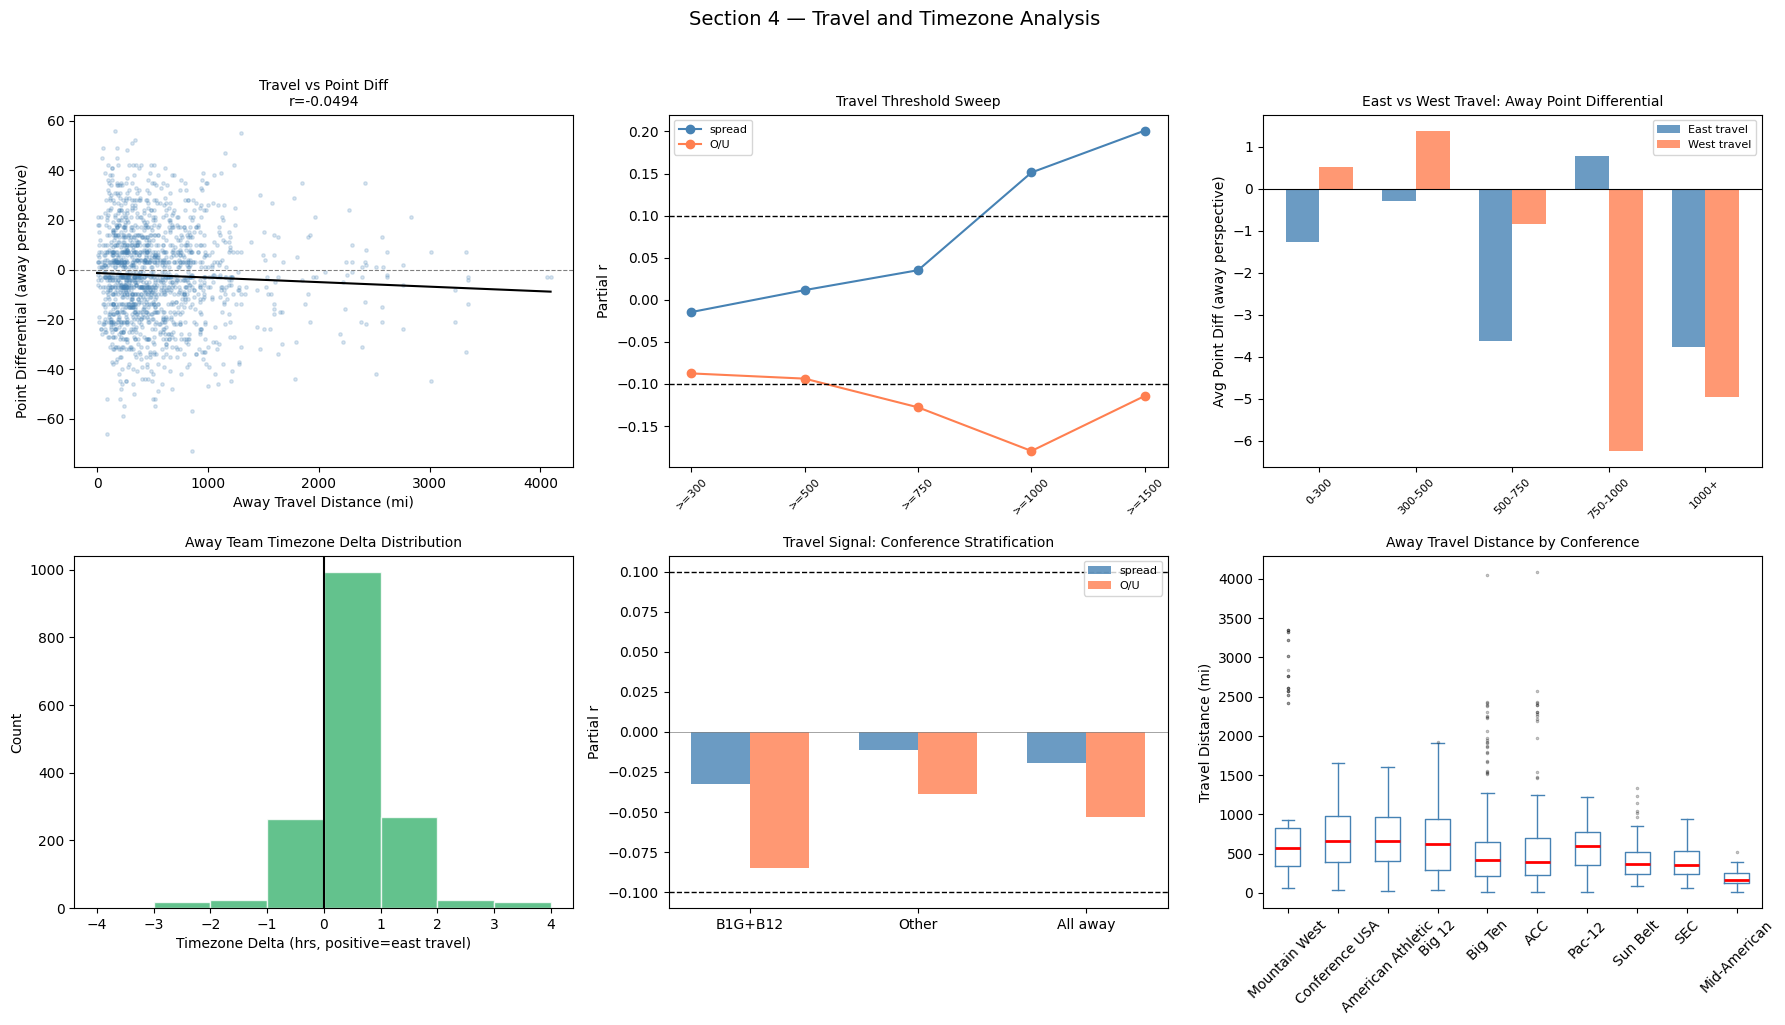

In [75]:
# Cell 24 — Section 4: Travel visualization

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Travel vs point_differential (away only)
sub = away_only[["away_travel_distance_mi","point_differential"]].dropna()
axes[0][0].scatter(sub["away_travel_distance_mi"], sub["point_differential"],
                   alpha=0.2, s=6, color="steelblue")
m, b = np.polyfit(sub["away_travel_distance_mi"], sub["point_differential"], 1)
xl = np.linspace(0, sub["away_travel_distance_mi"].max(), 200)
axes[0][0].plot(xl, m*xl+b, color="black", lw=1.5)
r, _ = stats.pearsonr(sub["away_travel_distance_mi"], sub["point_differential"])
axes[0][0].set_xlabel("Away Travel Distance (mi)")
axes[0][0].set_ylabel("Point Differential (away perspective)")
axes[0][0].set_title(f"Travel vs Point Diff\nr={r:.4f}", fontsize=10)
axes[0][0].axhline(0, color="gray", lw=0.8, ls="--")

# 2. Threshold sweep — travel vs point_differential
thresholds = [300, 500, 750, 1000, 1500]
r_vals_sp = [travel_threshold_results["point_differential"].get(t,{}).get("r",np.nan) for t in thresholds]
r_vals_ou = [travel_threshold_results["total_points"].get(t,{}).get("r",np.nan) for t in thresholds]
axes[0][1].plot(range(len(thresholds)), r_vals_sp, marker="o", color="steelblue", label="spread")
axes[0][1].plot(range(len(thresholds)), r_vals_ou, marker="o", color="coral", label="O/U")
axes[0][1].axhline(THRESHOLD,  color="black", lw=1, ls="--")
axes[0][1].axhline(-THRESHOLD, color="black", lw=1, ls="--")
axes[0][1].set_xticks(range(len(thresholds)))
axes[0][1].set_xticklabels([f">={t}" for t in thresholds], rotation=45, fontsize=8)
axes[0][1].set_ylabel("Partial r")
axes[0][1].set_title("Travel Threshold Sweep", fontsize=10)
axes[0][1].legend(fontsize=8)

# 3. East vs West travel — point_differential
east_means = east_travel.groupby(pd.cut(east_travel["away_travel_distance_mi"],
                                        bins=[0,300,500,750,1000,5000]))["point_differential"].mean()
west_means = west_travel.groupby(pd.cut(west_travel["away_travel_distance_mi"],
                                        bins=[0,300,500,750,1000,5000]))["point_differential"].mean()
labels_ew = ["0-300","300-500","500-750","750-1000","1000+"]
x = np.arange(len(labels_ew))
w = 0.35
axes[0][2].bar(x-w/2, east_means.values, w, label="East travel", color="steelblue", alpha=0.8)
axes[0][2].bar(x+w/2, west_means.values, w, label="West travel", color="coral", alpha=0.8)
axes[0][2].axhline(0, color="black", lw=0.8)
axes[0][2].set_xticks(x)
axes[0][2].set_xticklabels(labels_ew, rotation=45, fontsize=8)
axes[0][2].set_ylabel("Avg Point Diff (away perspective)")
axes[0][2].set_title("East vs West Travel: Away Point Differential", fontsize=10)
axes[0][2].legend(fontsize=8)

# 4. Timezone delta distribution
sub = away_only["away_tz_delta_hrs"].dropna()
axes[1][0].hist(sub, bins=range(int(sub.min())-1, int(sub.max())+2),
                color="mediumseagreen", alpha=0.8, edgecolor="white")
axes[1][0].set_xlabel("Timezone Delta (hrs, positive=east travel)")
axes[1][0].set_ylabel("Count")
axes[1][0].set_title("Away Team Timezone Delta Distribution", fontsize=10)
axes[1][0].axvline(0, color="black", lw=1.5)

# 5. Big Ten+B12 vs others
labels_b1g = ["B1G+B12","Other","All away"]
r_sp_b1g = [travel_conf_results.get((l,"point_differential"),{}).get("r",np.nan)
             for l in ["Big Ten + Big 12","All other conferences","Full away population"]]
r_ou_b1g = [travel_conf_results.get((l,"total_points"),{}).get("r",np.nan)
             for l in ["Big Ten + Big 12","All other conferences","Full away population"]]
x = np.arange(3)
axes[1][1].bar(x-w/2, r_sp_b1g, w, label="spread", color="steelblue", alpha=0.8)
axes[1][1].bar(x+w/2, r_ou_b1g, w, label="O/U",    color="coral",    alpha=0.8)
axes[1][1].axhline(THRESHOLD,  color="black", lw=1, ls="--")
axes[1][1].axhline(-THRESHOLD, color="black", lw=1, ls="--")
axes[1][1].axhline(0, color="gray", lw=0.5)
axes[1][1].set_xticks(x)
axes[1][1].set_xticklabels(labels_b1g)
axes[1][1].set_ylabel("Partial r")
axes[1][1].set_title("Travel Signal: Conference Stratification", fontsize=10)
axes[1][1].legend(fontsize=8)

# 6. Travel distance distribution by conference
conf_order_t = away_only.groupby("conference")["away_travel_distance_mi"].mean().sort_values(ascending=False).index
data_by_conf_t = [away_only[away_only["conference"]==c]["away_travel_distance_mi"].dropna().values
                  for c in conf_order_t]
axes[1][2].boxplot(data_by_conf_t, labels=conf_order_t,
                   boxprops=dict(color="steelblue"),
                   medianprops=dict(color="red", lw=2),
                   whiskerprops=dict(color="steelblue"),
                   capprops=dict(color="steelblue"),
                   flierprops=dict(marker=".", alpha=0.3, ms=3))
axes[1][2].set_title("Away Travel Distance by Conference", fontsize=10)
axes[1][2].set_ylabel("Travel Distance (mi)")
axes[1][2].tick_params(axis="x", rotation=45)

plt.suptitle("Section 4 — Travel and Timezone Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [76]:
# Cell 25 — Section 5: Weather — temperature individual component

print("=" * 70)
print("SECTION 5 — WEATHER ANALYSIS (dome games excluded throughout)")
print("=" * 70)

print("\n=== 5a: Temperature — individual component ===\n")
print(f"Non-dome games: {len(non_dome):,}")

# Temperature bins
non_dome_q = non_dome.copy()
non_dome_q["temp_bin"] = pd.cut(
    non_dome_q["temperature_f"],
    bins=[-np.inf, 25, 40, 55, 70, 85, np.inf],
    labels=["<25°F","25-40°F","40-55°F","55-70°F","70-85°F",">85°F"]
)

print(f"\nScoring by temperature bin:")
print(f"  {'Bin':10s} {'n':>6} {'total_pts_mean':>16} {'point_diff_mean':>16} {'sd_total':>10}")
print(f"  {'-'*65}")
for bin_label in ["<25°F","25-40°F","40-55°F","55-70°F","70-85°F",">85°F"]:
    sub_bin = non_dome_q[non_dome_q["temp_bin"]==bin_label]
    if len(sub_bin) < 5:
        continue
    print(f"  {bin_label:10s} {len(sub_bin):>6,} "
          f"{sub_bin['total_points'].mean():>16.2f} "
          f"{sub_bin['point_differential'].mean():>+16.2f} "
          f"{sub_bin['total_points'].std():>10.2f}")

# Partial r continuous
print(f"\n{'Feature':25s} {'target':25s} {'partial_r':>10} {'p':>10} {'n':>8} {'signal':>8}")
print("-" * 80)
temp_results = {}
for target in ["point_differential","total_points"]:
    r, p, n = partial_corr(non_dome, "temperature_f", target, EPA_ANCHOR)
    signal = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
    r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
    print(f"  {'temperature_f':23s} {target:25s} {r_str:>10} {p:>10.4f} {n:>8,} {signal:>8}")
    temp_results[target] = {"r": r, "p": p, "n": n}

# Cold threshold analysis
print(f"\n--- Cold threshold analysis ---")
for thresh in [25, 40, 55]:
    sub_cold = non_dome[non_dome["temperature_f"] <= thresh]
    for target in ["total_points"]:
        r, p, n = partial_corr(sub_cold, "temperature_f", target, EPA_ANCHOR)
        signal = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
        r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
        print(f"  temp <= {thresh}°F  {target:25s} partial_r={r_str}  n={n:,}  {signal}")

SECTION 5 — WEATHER ANALYSIS (dome games excluded throughout)

=== 5a: Temperature — individual component ===

Non-dome games: 3,104

Scoring by temperature bin:
  Bin             n   total_pts_mean  point_diff_mean   sd_total
  -----------------------------------------------------------------
  <25°F          34            41.82            +0.00      16.12
  25-40°F       194            51.15            +0.00      15.82
  40-55°F       686            52.75            +0.00      16.87
  55-70°F     1,118            54.20            +0.00      17.92
  70-85°F       900            54.95            +0.00      17.24
  >85°F         160            53.96            +0.00      16.52

Feature                   target                     partial_r          p        n   signal
--------------------------------------------------------------------------------
  temperature_f           point_differential           -0.0000     1.0000    3,086        ✗
  temperature_f           total_points           

In [77]:
# Cell 26 — Section 5: Weather — wind individual component

print("=== 5b: Wind — individual component ===\n")

print(f"{'Feature':25s} {'target':25s} {'partial_r':>10} {'p':>10} {'n':>8} {'signal':>8}")
print("-" * 80)
wind_results = {}
for feat in ["wind_speed_mph","wind_gusts_mph","is_high_wind"]:
    for target in ["point_differential","total_points"]:
        r, p, n = partial_corr(non_dome, feat, target, EPA_ANCHOR)
        signal = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
        r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
        print(f"  {feat:23s} {target:25s} {r_str:>10} {p:>10.4f} {n:>8,} {signal:>8}")
        wind_results[(feat, target)] = {"r": r, "p": p, "n": n}

# Wind asymmetry: home vs away
print(f"\n--- Wind asymmetry: home vs away scoring response ---")
home_nd = non_dome[non_dome["is_home_team"] == 1].copy()
away_nd = non_dome[non_dome["is_away_team"] == 1].copy()
for feat in ["wind_speed_mph","is_high_wind"]:
    r_home, p_home, n_home = partial_corr(home_nd, feat, "points_scored", EPA_ANCHOR)
    r_away, p_away, n_away = partial_corr(away_nd, feat, "points_scored", EPA_ANCHOR)
    diff = (abs(r_home) if not np.isnan(r_home) else 0) - \
           (abs(r_away) if not np.isnan(r_away) else 0)
    print(f"  {feat}:")
    print(f"    Home partial_r={r_home:.4f}  n={n_home:,}")
    print(f"    Away partial_r={r_away:.4f}  n={n_away:,}")
    print(f"    Asymmetry: {diff:+.4f}  "
          f"{'✓ asymmetric (spread signal)' if abs(diff) > 0.05 else '✗ symmetric (O/U signal only)'}")

=== 5b: Wind — individual component ===

Feature                   target                     partial_r          p        n   signal
--------------------------------------------------------------------------------
  wind_speed_mph          point_differential            0.0000     1.0000    3,086        ✗
  wind_speed_mph          total_points                  0.0009     0.9581    3,086        ✗
  wind_gusts_mph          point_differential           -0.0000     1.0000    3,086        ✗
  wind_gusts_mph          total_points                  0.0114     0.5277    3,086        ✗
  is_high_wind            point_differential            0.0000     1.0000    3,086        ✗
  is_high_wind            total_points                  0.0280     0.1196    3,086        ✗

--- Wind asymmetry: home vs away scoring response ---
  wind_speed_mph:
    Home partial_r=-0.0013  n=1,543
    Away partial_r=0.0032  n=1,543
    Asymmetry: -0.0019  ✗ symmetric (O/U signal only)
  is_high_wind:
    Home partial_r=0

In [78]:
# Cell 27 — Section 5: Weather — humidity individual component

print("=== 5c: Humidity — individual component ===\n")

non_dome_q = non_dome.copy()
non_dome_q["humidity_bin"] = pd.cut(
    non_dome_q["humidity_pct"],
    bins=[0, 30, 50, 65, 80, 100],
    labels=["<30%","30-50%","50-65%","65-80%",">80%"]
)

print(f"Scoring by humidity bin:")
print(f"  {'Bin':10s} {'n':>6} {'total_pts_mean':>16} {'point_diff_mean':>16}")
print(f"  {'-'*55}")
for bin_label in ["<30%","30-50%","50-65%","65-80%",">80%"]:
    sub_bin = non_dome_q[non_dome_q["humidity_bin"]==bin_label]
    if len(sub_bin) < 5:
        continue
    print(f"  {bin_label:10s} {len(sub_bin):>6,} "
          f"{sub_bin['total_points'].mean():>16.2f} "
          f"{sub_bin['point_differential'].mean():>+16.2f}")

print(f"\n{'Feature':25s} {'target':25s} {'partial_r':>10} {'p':>10} {'n':>8} {'signal':>8}")
print("-" * 80)
humidity_results = {}
for target in ["point_differential","total_points"]:
    r, p, n = partial_corr(non_dome, "humidity_pct", target, EPA_ANCHOR)
    signal = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
    r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
    print(f"  {'humidity_pct':23s} {target:25s} {r_str:>10} {p:>10.4f} {n:>8,} {signal:>8}")
    humidity_results[target] = {"r": r, "p": p, "n": n}

=== 5c: Humidity — individual component ===

Scoring by humidity bin:
  Bin             n   total_pts_mean  point_diff_mean
  -------------------------------------------------------
  <30%          290            52.86            +0.00
  30-50%      1,022            54.38            +0.00
  50-65%        898            53.33            +0.00
  65-80%        566            53.04            +0.00
  >80%          316            55.08            +0.00

Feature                   target                     partial_r          p        n   signal
--------------------------------------------------------------------------------
  humidity_pct            point_differential            0.0000     1.0000    3,086        ✗
  humidity_pct            total_points                  0.0096     0.5951    3,086        ✗


In [79]:
# Cell 28 — Section 5: Weather — wind chill composite vs components

print("=== 5d: Wind chill — composite vs components ===\n")
print("Wind chill = NWS formula, triggered when temp<50°F AND wind>3mph")
print("Key question: does composite explain more variance than temp or wind alone?\n")

# Wind chill triggered population
wc_pop = non_dome[
    (non_dome["temperature_f"] < 50) &
    (non_dome["wind_speed_mph"] > 3) &
    (non_dome["wind_chill"].notna())
].copy()
print(f"Wind chill triggered population: {len(wc_pop):,}")

print(f"\nWithin triggered population — composite vs component comparison:")
print(f"{'Feature':25s} {'target':25s} {'partial_r':>10} {'p':>10} {'n':>8} {'signal':>8}")
print("-" * 80)
wc_results = {}
for feat in ["temperature_f","wind_speed_mph","wind_chill"]:
    for target in ["point_differential","total_points"]:
        r, p, n = partial_corr(wc_pop, feat, target, EPA_ANCHOR)
        signal = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
        r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
        print(f"  {feat:23s} {target:25s} {r_str:>10} {p:>10.4f} {n:>8,} {signal:>8}")
        wc_results[(feat, target)] = {"r": r, "p": p, "n": n}

# Wind chill threshold analysis
print(f"\n--- Wind chill threshold analysis ---")
for thresh in [40, 25, 10]:
    sub_wc = wc_pop[wc_pop["wind_chill"] <= thresh]
    for target in ["total_points"]:
        r, p, n = partial_corr(sub_wc, "wind_chill", target, EPA_ANCHOR)
        signal = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
        r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
        print(f"  wind_chill <= {thresh}°F  {target:25s} partial_r={r_str}  n={n:,}  {signal}")

=== 5d: Wind chill — composite vs components ===

Wind chill = NWS formula, triggered when temp<50°F AND wind>3mph
Key question: does composite explain more variance than temp or wind alone?

Wind chill triggered population: 492

Within triggered population — composite vs component comparison:
Feature                   target                     partial_r          p        n   signal
--------------------------------------------------------------------------------
  temperature_f           point_differential            0.0000     1.0000      490        ✗
  temperature_f           total_points                  0.0306     0.4995      490        ✗
  wind_speed_mph          point_differential            0.0000     1.0000      490        ✗
  wind_speed_mph          total_points                  0.0233     0.6066      490        ✗
  wind_chill              point_differential            0.0000     1.0000      490        ✗
  wind_chill              total_points                  0.0334     0.460

In [80]:
# Cell 29 — Section 5: Weather — heat index composite vs components

print("=== 5e: Heat index — composite vs components ===\n")
print("Heat index = Rothfusz, triggered when temp>80°F AND humidity>40%")
print("Key question: does composite explain more variance than temp or humidity alone?\n")

# Heat index triggered population
hi_pop = non_dome[
    (non_dome["temperature_f"] > 80) &
    (non_dome["humidity_pct"] > 40) &
    (non_dome["heat_index"].notna())
].copy()
print(f"Heat index triggered population: {len(hi_pop):,}")

print(f"\nWithin triggered population — composite vs component comparison:")
print(f"{'Feature':25s} {'target':25s} {'partial_r':>10} {'p':>10} {'n':>8} {'signal':>8}")
print("-" * 80)
hi_results = {}
for feat in ["temperature_f","humidity_pct","heat_index"]:
    for target in ["point_differential","total_points"]:
        r, p, n = partial_corr(hi_pop, feat, target, EPA_ANCHOR)
        signal = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
        r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
        print(f"  {feat:23s} {target:25s} {r_str:>10} {p:>10.4f} {n:>8,} {signal:>8}")
        hi_results[(feat, target)] = {"r": r, "p": p, "n": n}

# Heat index threshold analysis
print(f"\n--- Heat index threshold analysis ---")
for thresh in [90, 100, 105]:
    sub_hi = hi_pop[hi_pop["heat_index"] >= thresh]
    for target in ["total_points"]:
        r, p, n = partial_corr(sub_hi, "heat_index", target, EPA_ANCHOR)
        signal = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
        r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
        print(f"  heat_index >= {thresh}°F  {target:25s} partial_r={r_str}  n={n:,}  {signal}")

=== 5e: Heat index — composite vs components ===

Heat index = Rothfusz, triggered when temp>80°F AND humidity>40%
Key question: does composite explain more variance than temp or humidity alone?

Heat index triggered population: 214

Within triggered population — composite vs component comparison:
Feature                   target                     partial_r          p        n   signal
--------------------------------------------------------------------------------
  temperature_f           point_differential           -0.0000     1.0000      214        ✗
  temperature_f           total_points                 -0.0595     0.3866      214        ✗
  humidity_pct            point_differential            0.0000     1.0000      214        ✗
  humidity_pct            total_points                 -0.0257     0.7087      214        ✗
  heat_index              point_differential            0.0000     1.0000      214        ✗
  heat_index              total_points                 -0.0788     0

In [81]:
# Cell 30 — Section 5: Weather — precipitation

print("=== 5f: Precipitation ===\n")
print("NOTE: Small sample — conditional verdict logic applies.")
print("Do not include unless |r| >= 0.10 AND n >= 200.\n")

precip_games = non_dome[non_dome["is_precipitation"] == 1].copy()
dry_games    = non_dome[non_dome["is_precipitation"] == 0].copy()

print(f"Precipitation games (non-dome): {len(precip_games):,}")
print(f"Dry games (non-dome)          : {len(dry_games):,}")

# n check
n_precip = len(precip_games)
if n_precip < 200:
    print(f"\n⚠ SAMPLE SIZE FLAG: n={n_precip} < 200 threshold.")
    print(f"  Verdict will be: 'insufficient sample — do not model' unless |r| >= 0.10 AND n >= 200")

print(f"\n{'Feature':25s} {'target':25s} {'partial_r':>10} {'p':>10} {'n':>8} {'signal':>8}")
print("-" * 80)
precip_results = {}
for feat in ["precipitation_inches","is_precipitation"]:
    for target in ["point_differential","total_points"]:
        r, p, n = partial_corr(non_dome, feat, target, EPA_ANCHOR)
        signal = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
        r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
        print(f"  {feat:23s} {target:25s} {r_str:>10} {p:>10.4f} {n:>8,} {signal:>8}")
        precip_results[(feat, target)] = {"r": r, "p": p, "n": n}

# Scoring in precip vs dry
print(f"\nScoring comparison: precipitation vs dry games")
for target in ["total_points","point_differential"]:
    t, p = stats.ttest_ind(
        precip_games[target].dropna(),
        dry_games[target].dropna()
    )
    print(f"  {target:25s} precip={precip_games[target].mean():.2f}  "
          f"dry={dry_games[target].mean():.2f}  "
          f"diff={precip_games[target].mean()-dry_games[target].mean():+.2f}  "
          f"p={p:.4f}  {'✓' if p<0.05 else '✗'}")

=== 5f: Precipitation ===

NOTE: Small sample — conditional verdict logic applies.
Do not include unless |r| >= 0.10 AND n >= 200.

Precipitation games (non-dome): 44
Dry games (non-dome)          : 3,048

⚠ SAMPLE SIZE FLAG: n=44 < 200 threshold.
  Verdict will be: 'insufficient sample — do not model' unless |r| >= 0.10 AND n >= 200

Feature                   target                     partial_r          p        n   signal
--------------------------------------------------------------------------------
  precipitation_inches    point_differential           -0.0000     1.0000    3,086        ✗
  precipitation_inches    total_points                  0.0116     0.5198    3,086        ✗
  is_precipitation        point_differential            0.0000     1.0000    3,086        ✗
  is_precipitation        total_points                  0.0159     0.3775    3,086        ✗

Scoring comparison: precipitation vs dry games
  total_points              precip=51.14  dry=53.80  diff=-2.66  p=0.3127 

In [82]:
# Cell 31 — Section 5: Weather — dome vs non-dome residual SD comparison

print("=== 5g: Dome vs non-dome residual SD comparison ===\n")
print("After EPA anchor pair, is residual SD lower in dome games?")
print("Lower residual SD in dome = dome games are more predictable.\n")

for target in ["total_points","point_differential"]:
    sub_all = gdf_conf[EPA_ANCHOR + [target, "is_dome"]].dropna()
    X = sub_all[EPA_ANCHOR].values
    y = sub_all[target].values
    reg = LinearRegression().fit(X, y)
    sub_all = sub_all.copy()
    sub_all["resid"] = y - reg.predict(X)

    dome_resid    = sub_all[sub_all["is_dome"]==1]["resid"]
    non_dome_resid = sub_all[sub_all["is_dome"]==0]["resid"]

    print(f"  {target}:")
    print(f"    Dome residual SD    : {dome_resid.std():.4f}  n={len(dome_resid):,}")
    print(f"    Non-dome residual SD: {non_dome_resid.std():.4f}  n={len(non_dome_resid):,}")
    levene_stat, levene_p = stats.levene(dome_resid, non_dome_resid)
    print(f"    Levene test p={levene_p:.4f}  "
          f"{'✓ dome is more predictable' if levene_p < 0.05 and dome_resid.std() < non_dome_resid.std() else '✗ no significant difference'}")
    print()

=== 5g: Dome vs non-dome residual SD comparison ===

After EPA anchor pair, is residual SD lower in dome games?
Lower residual SD in dome = dome games are more predictable.

  total_points:
    Dome residual SD    : 12.2427  n=114
    Non-dome residual SD: 12.6934  n=3,098
    Levene test p=0.4500  ✗ no significant difference

  point_differential:
    Dome residual SD    : 9.4766  n=114
    Non-dome residual SD: 9.1588  n=3,098
    Levene test p=0.5847  ✗ no significant difference



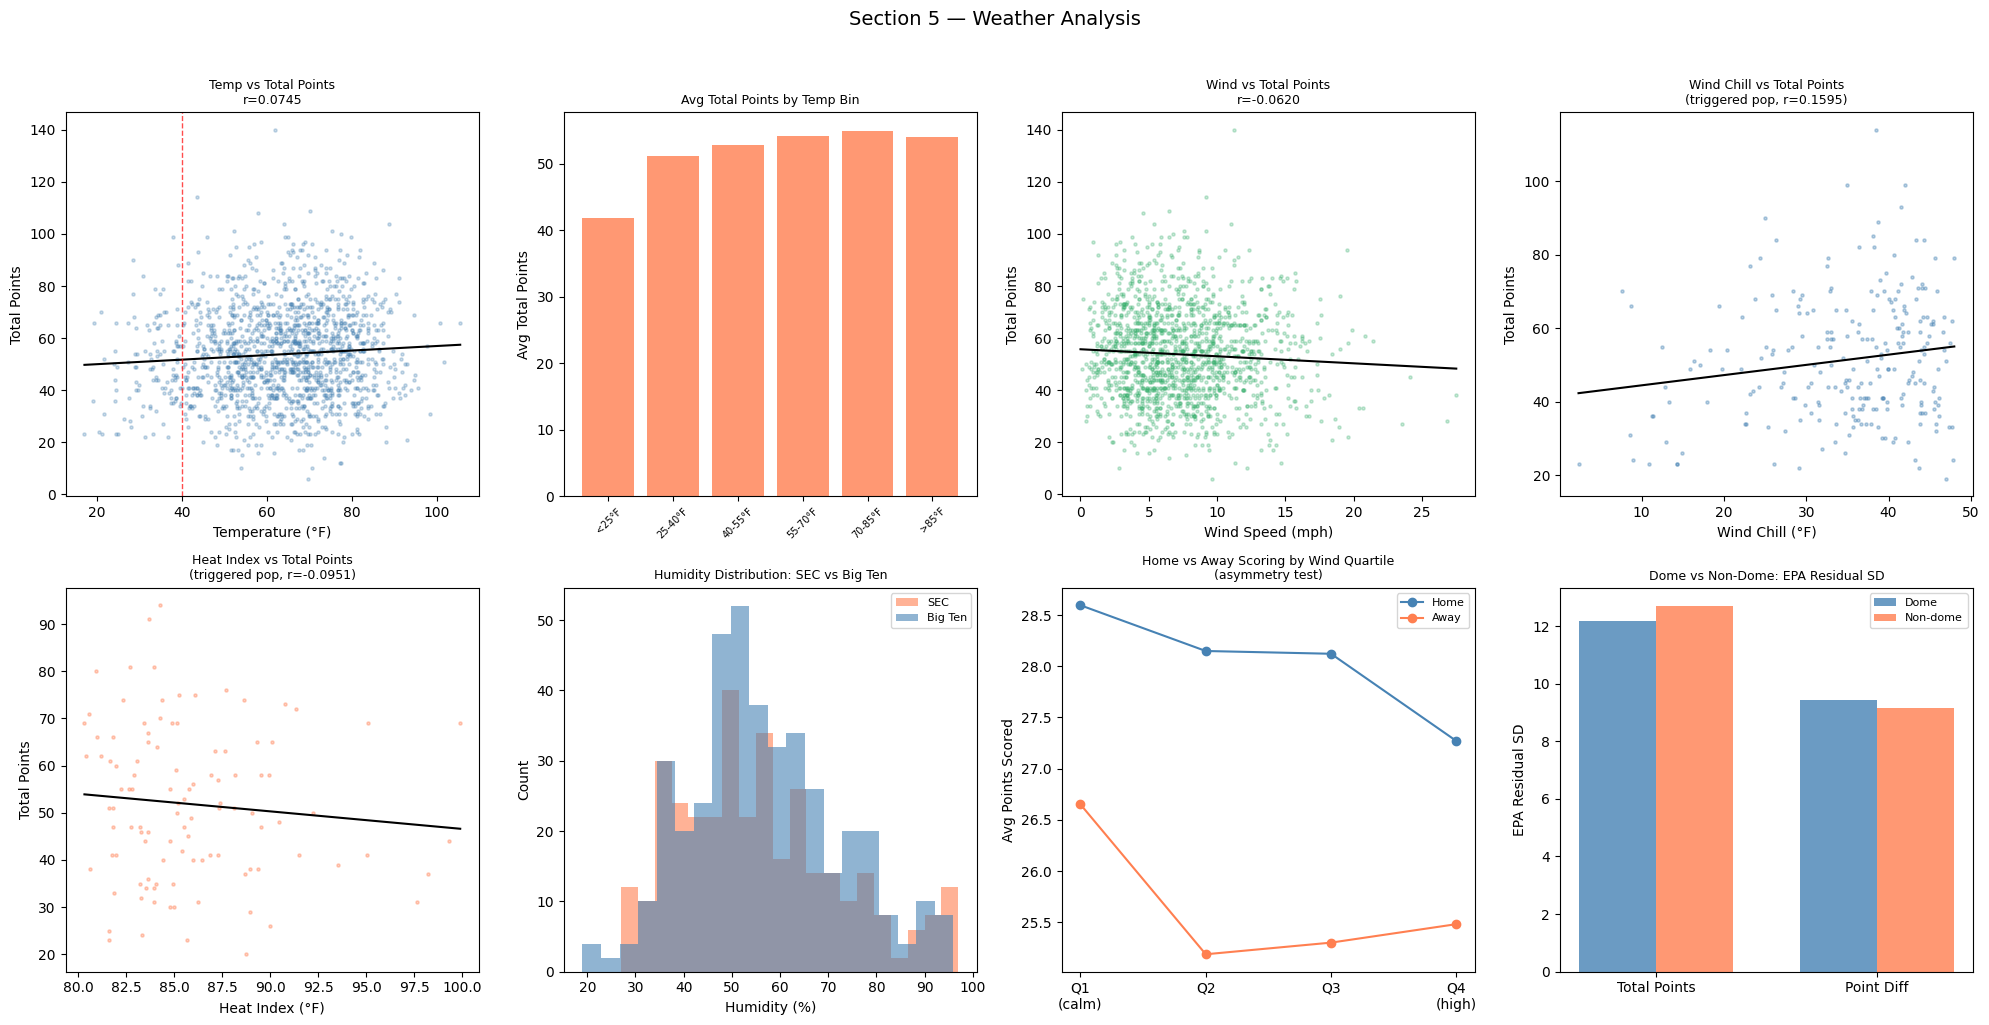

In [83]:
# Cell 32 — Section 5: Weather visualization

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# 1. Temperature vs total_points
sub = non_dome[["temperature_f","total_points"]].dropna()
axes[0][0].scatter(sub["temperature_f"], sub["total_points"],
                   alpha=0.15, s=5, color="steelblue")
m, b = np.polyfit(sub["temperature_f"], sub["total_points"], 1)
xl = np.linspace(sub["temperature_f"].min(), sub["temperature_f"].max(), 200)
axes[0][0].plot(xl, m*xl+b, color="black", lw=1.5)
r, _ = stats.pearsonr(sub["temperature_f"], sub["total_points"])
axes[0][0].axvline(40, color="red", lw=1, ls="--", alpha=0.7)
axes[0][0].set_xlabel("Temperature (°F)")
axes[0][0].set_ylabel("Total Points")
axes[0][0].set_title(f"Temp vs Total Points\nr={r:.4f}", fontsize=9)

# 2. Total points by temp bin — use non_dome_temp_q (separate variable)
non_dome_temp_q = non_dome.copy()
non_dome_temp_q["temp_bin"] = pd.cut(
    non_dome_temp_q["temperature_f"],
    bins=[-np.inf, 25, 40, 55, 70, 85, np.inf],
    labels=["<25°F","25-40°F","40-55°F","55-70°F","70-85°F",">85°F"]
)
bins_t  = ["<25°F","25-40°F","40-55°F","55-70°F","70-85°F",">85°F"]
means_t = [non_dome_temp_q[non_dome_temp_q["temp_bin"]==b]["total_points"].mean() for b in bins_t]
axes[0][1].bar(range(len(bins_t)), means_t, color="coral", alpha=0.8)
axes[0][1].set_xticks(range(len(bins_t)))
axes[0][1].set_xticklabels(bins_t, rotation=45, fontsize=7)
axes[0][1].set_ylabel("Avg Total Points")
axes[0][1].set_title("Avg Total Points by Temp Bin", fontsize=9)

# 3. Wind speed vs total_points
sub = non_dome[["wind_speed_mph","total_points"]].dropna()
axes[0][2].scatter(sub["wind_speed_mph"], sub["total_points"],
                   alpha=0.15, s=5, color="mediumseagreen")
m, b = np.polyfit(sub["wind_speed_mph"], sub["total_points"], 1)
xl = np.linspace(0, sub["wind_speed_mph"].max(), 200)
axes[0][2].plot(xl, m*xl+b, color="black", lw=1.5)
r, _ = stats.pearsonr(sub["wind_speed_mph"], sub["total_points"])
axes[0][2].set_xlabel("Wind Speed (mph)")
axes[0][2].set_ylabel("Total Points")
axes[0][2].set_title(f"Wind vs Total Points\nr={r:.4f}", fontsize=9)

# 4. Wind chill vs total_points (triggered pop)
sub = wc_pop[["wind_chill","total_points"]].dropna()
if len(sub) > 10:
    axes[0][3].scatter(sub["wind_chill"], sub["total_points"],
                       alpha=0.2, s=5, color="steelblue")
    m, b = np.polyfit(sub["wind_chill"], sub["total_points"], 1)
    xl = np.linspace(sub["wind_chill"].min(), sub["wind_chill"].max(), 200)
    axes[0][3].plot(xl, m*xl+b, color="black", lw=1.5)
    r, _ = stats.pearsonr(sub["wind_chill"], sub["total_points"])
    axes[0][3].set_title(f"Wind Chill vs Total Points\n(triggered pop, r={r:.4f})", fontsize=9)
else:
    axes[0][3].set_title("Wind Chill: insufficient sample", fontsize=9)
axes[0][3].set_xlabel("Wind Chill (°F)")
axes[0][3].set_ylabel("Total Points")

# 5. Heat index vs total_points (triggered pop)
sub = hi_pop[["heat_index","total_points"]].dropna()
if len(sub) > 10:
    axes[1][0].scatter(sub["heat_index"], sub["total_points"],
                       alpha=0.2, s=5, color="coral")
    m, b = np.polyfit(sub["heat_index"], sub["total_points"], 1)
    xl = np.linspace(sub["heat_index"].min(), sub["heat_index"].max(), 200)
    axes[1][0].plot(xl, m*xl+b, color="black", lw=1.5)
    r, _ = stats.pearsonr(sub["heat_index"], sub["total_points"])
    axes[1][0].set_title(f"Heat Index vs Total Points\n(triggered pop, r={r:.4f})", fontsize=9)
else:
    axes[1][0].set_title("Heat Index: insufficient sample", fontsize=9)
axes[1][0].set_xlabel("Heat Index (°F)")
axes[1][0].set_ylabel("Total Points")

# 6. Humidity by conference (SEC vs Big Ten)
for conf, color in [("SEC","coral"),("Big Ten","steelblue")]:
    sub = non_dome[non_dome["conference"]==conf]["humidity_pct"].dropna()
    if len(sub) > 0:
        axes[1][1].hist(sub, bins=20, alpha=0.6, color=color, label=conf)
axes[1][1].set_xlabel("Humidity (%)")
axes[1][1].set_ylabel("Count")
axes[1][1].set_title("Humidity Distribution: SEC vs Big Ten", fontsize=9)
axes[1][1].legend(fontsize=8)

# 7. Home vs away scoring by wind quartile — use separate variable name
non_dome_wind_q = non_dome.copy()
non_dome_wind_q["wind_q"] = pd.qcut(
    non_dome_wind_q["wind_speed_mph"].fillna(0), q=4,
    labels=["Q1\n(calm)","Q2","Q3","Q4\n(high)"]
)
home_wq = non_dome_wind_q[non_dome_wind_q["is_home_team"]==1].groupby("wind_q")["points_scored"].mean()
away_wq = non_dome_wind_q[non_dome_wind_q["is_away_team"]==1].groupby("wind_q")["points_scored"].mean()
x = np.arange(4)
axes[1][2].plot(x, home_wq.values, marker="o", color="steelblue", label="Home")
axes[1][2].plot(x, away_wq.values, marker="o", color="coral", label="Away")
axes[1][2].set_xticks(x)
axes[1][2].set_xticklabels(["Q1\n(calm)","Q2","Q3","Q4\n(high)"])
axes[1][2].set_ylabel("Avg Points Scored")
axes[1][2].set_title("Home vs Away Scoring by Wind Quartile\n(asymmetry test)", fontsize=9)
axes[1][2].legend(fontsize=8)

# 8. Dome vs non-dome residual SD
targets_dome = ["total_points","point_differential"]
dome_sds    = []
nondome_sds = []
for target in targets_dome:
    sub_all = gdf_conf[EPA_ANCHOR + [target, "is_dome"]].dropna()
    X = sub_all[EPA_ANCHOR].values
    y = sub_all[target].values
    reg = LinearRegression().fit(X, y)
    resid = y - reg.predict(X)
    is_dome_arr = sub_all["is_dome"].values
    dome_sds.append(np.std(resid[is_dome_arr==1]))
    nondome_sds.append(np.std(resid[is_dome_arr==0]))
x = np.arange(len(targets_dome))
w = 0.35
axes[1][3].bar(x-w/2, dome_sds,    w, label="Dome",     color="steelblue", alpha=0.8)
axes[1][3].bar(x+w/2, nondome_sds, w, label="Non-dome", color="coral",    alpha=0.8)
axes[1][3].set_xticks(x)
axes[1][3].set_xticklabels(["Total Points","Point Diff"])
axes[1][3].set_ylabel("EPA Residual SD")
axes[1][3].set_title("Dome vs Non-Dome: EPA Residual SD", fontsize=9)
axes[1][3].legend(fontsize=8)

plt.suptitle("Section 5 — Weather Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [84]:
# Cell 33 — Section 6: Conference-stratified summary table
# Six populations as specified:
# 1. Full away population
# 2. Mountain West + Big 12 (elevation)
# 3. Big Ten + Big 12 (travel)
# 4. Non-dome games
# 5. Elevation delta > 3000 ft
# 6. Travel > 500 miles

print("=" * 70)
print("SECTION 6 — CONFERENCE-STRATIFIED SUMMARY TABLE")
print("=" * 70)
print("\nPartial r after EPA anchor pair — all six populations\n")

populations = {
    "Full away population":    away_only,
    "Mountain West + Big 12":  away_only[away_only["conference"].isin(["Mountain West","Big 12"])],
    "Big Ten + Big 12":        away_only[away_only["conference"].isin(["Big Ten","Big 12"])],
    "Non-dome games":          non_dome,
    "Elev delta > 3000 ft":   away_only[away_only["away_elevation_delta_ft"] >= 3000],
    "Travel > 500 mi":        away_only[away_only["away_travel_distance_mi"] >= 500],
}

features_to_test = [
    "away_elevation_delta_ft",
    "away_travel_distance_mi",
    "away_tz_delta_hrs",
    "wind_speed_mph",
    "wind_chill",
    "heat_index",
    "temperature_f",
    "humidity_pct",
]

print(f"{'Population':28s} {'Feature':30s} {'spread_r':>10} {'ou_r':>10} {'n':>8}")
print("-" * 90)
conf_strat_results = {}
for pop_name, pop_df in populations.items():
    for feat in features_to_test:
        if feat not in pop_df.columns:
            continue
        r_sp, p_sp, n = partial_corr(pop_df, feat, "point_differential", EPA_ANCHOR)
        r_ou, p_ou, _ = partial_corr(pop_df, feat, "total_points", EPA_ANCHOR)
        sp_str = f"{r_sp:.4f}" if not np.isnan(r_sp) else "  nan "
        ou_str = f"{r_ou:.4f}" if not np.isnan(r_ou) else "  nan "
        sp_sig = "✓" if not np.isnan(r_sp) and abs(r_sp) >= THRESHOLD else " "
        ou_sig = "✓" if not np.isnan(r_ou) and abs(r_ou) >= THRESHOLD else " "
        print(f"  {pop_name:26s} {feat:30s} {sp_str+sp_sig:>11} {ou_str+ou_sig:>11} {n:>8,}")
        conf_strat_results[(pop_name, feat)] = {"spread_r": r_sp, "ou_r": r_ou, "n": n}
    print()

SECTION 6 — CONFERENCE-STRATIFIED SUMMARY TABLE

Partial r after EPA anchor pair — all six populations

Population                   Feature                          spread_r       ou_r        n
------------------------------------------------------------------------------------------
  Full away population       away_elevation_delta_ft           -0.0152      0.0132     1,606
  Full away population       away_travel_distance_mi           -0.0195     -0.0528     1,586
  Full away population       away_tz_delta_hrs                 -0.0313      0.0089     1,606
  Full away population       wind_speed_mph                     0.0174     -0.0047     1,600
  Full away population       wind_chill                         0.0588      0.0047     1,543
  Full away population       heat_index                         0.0612     -0.0014     1,543
  Full away population       temperature_f                      0.0559      0.0028     1,600
  Full away population       humidity_pct                      

In [85]:
# Cell 33a — Load kickoff_hour and join to conference game data

cur.execute("""
    SELECT game_id, kickoff_hour
    FROM stg.stg_game_weather
    WHERE kickoff_hour IS NOT NULL
""")
kick_rows = cur.fetchall()
kick_df = pd.DataFrame(kick_rows, columns=["game_id","kickoff_hour"])
kick_df["kickoff_hour"] = kick_df["kickoff_hour"].astype(float)

# Merge into away_only
away_kick = away_only.merge(kick_df, on="game_id", how="left")

print(f"Away team rows with kickoff_hour: {away_kick['kickoff_hour'].notna().sum():,} "
      f"of {len(away_kick):,} ({away_kick['kickoff_hour'].notna().mean()*100:.1f}%)")

print(f"\nKickoff hour distribution (away team conference games):")
print(away_kick["kickoff_hour"].value_counts().sort_index().to_string())

# Define kickoff buckets
def kickoff_bucket(h):
    if pd.isna(h):
        return np.nan
    if h <= 12:
        return "early (<=12 ET)"
    elif h <= 15:
        return "afternoon (13-15 ET)"
    elif h <= 18:
        return "evening (16-18 ET)"
    else:
        return "night (19+ ET)"

away_kick["kickoff_bucket"] = away_kick["kickoff_hour"].apply(kickoff_bucket)

print(f"\nKickoff bucket counts:")
print(away_kick["kickoff_bucket"].value_counts().to_string())

Away team rows with kickoff_hour: 1,603 of 1,609 (99.6%)

Kickoff hour distribution (away team conference games):
kickoff_hour
10.0      5
11.0    112
12.0    208
13.0     67
14.0    223
15.0    235
16.0     85
17.0     48
18.0    238
19.0    293
20.0     89

Kickoff bucket counts:
kickoff_bucket
afternoon (13-15 ET)    525
night (19+ ET)          382
evening (16-18 ET)      371
early (<=12 ET)         325


=== KICKOFF TIME × TIMEZONE INTERACTION ===

kickoff_hour is in ET. Large tz loss = away_tz_delta_hrs >= 2
(positive delta = away team traveling east, losing hours)

Populations:
  Large tz loss (>=2hr)              : 43
  Large tz loss + early kickoff (<=12): 8
  Large tz loss + late kickoff (>15) : 22
  No significant tz shift (<2hr)     : 1,524

--- Partial r after EPA anchor pair ---

Population                                    target                     partial_r          p        n   signal
---------------------------------------------------------------------------------------------------------
  Large tz loss (>=2hr), any kickoff          point_differential            0.0569     0.7172       43        ✗
  Large tz loss (>=2hr), any kickoff          total_points                 -0.0981     0.5315       43        ✗
  Large tz loss + early kickoff (<=12 ET)     point_differential              nan         nan        8        ✗
  Large tz loss + early kickoff (<=12 ET)     total_po

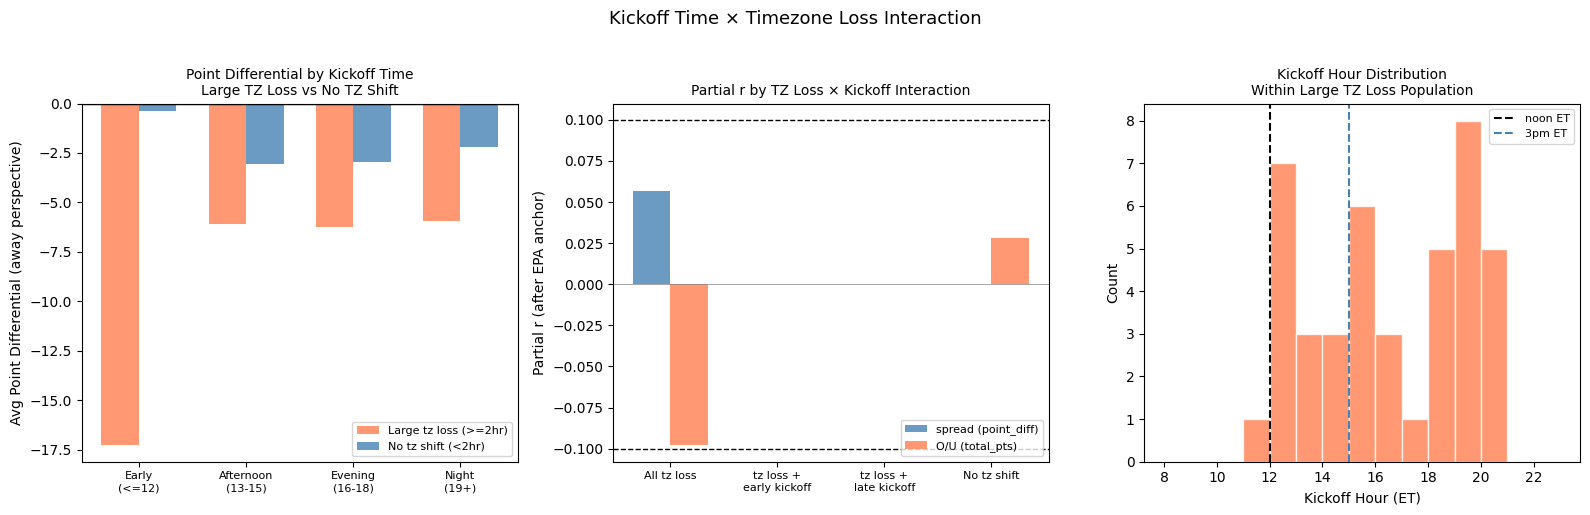


Best population for verdict: Large tz loss + early kickoff (<=12 ET)
  spread partial_r = nan  n=8
  O/U partial_r    = nan


In [86]:
# Cell 33b — Kickoff time × timezone interaction analysis
# Key question: does early kickoff compound the effect of large timezone loss?
# A west coast team traveling east to a noon ET game plays at 9am body clock.
# This is the maximum disruption scenario.

print("=== KICKOFF TIME × TIMEZONE INTERACTION ===\n")
print("kickoff_hour is in ET. Large tz loss = away_tz_delta_hrs >= 2")
print("(positive delta = away team traveling east, losing hours)\n")

# Define interaction populations
tz_loss    = away_kick[away_kick["away_tz_delta_hrs"] >= 2].copy()
tz_loss_early = tz_loss[tz_loss["kickoff_hour"] <= 12].copy()
tz_loss_late  = tz_loss[tz_loss["kickoff_hour"] > 15].copy()
tz_neutral = away_kick[away_kick["away_tz_delta_hrs"].abs() < 2].copy()

print(f"Populations:")
print(f"  Large tz loss (>=2hr)              : {len(tz_loss):,}")
print(f"  Large tz loss + early kickoff (<=12): {len(tz_loss_early):,}")
print(f"  Large tz loss + late kickoff (>15) : {len(tz_loss_late):,}")
print(f"  No significant tz shift (<2hr)     : {len(tz_neutral):,}")

print(f"\n--- Partial r after EPA anchor pair ---")
print(f"\n{'Population':45s} {'target':25s} {'partial_r':>10} {'p':>10} {'n':>8} {'signal':>8}")
print("-" * 105)

kickoff_tz_results = {}
for subset, label in [
    (tz_loss,       "Large tz loss (>=2hr), any kickoff"),
    (tz_loss_early, "Large tz loss + early kickoff (<=12 ET)"),
    (tz_loss_late,  "Large tz loss + late kickoff (>15 ET)"),
    (tz_neutral,    "No significant tz shift (<2hr)"),
]:
    for target in ["point_differential","total_points"]:
        r, p, n = partial_corr(subset, "away_tz_delta_hrs", target, EPA_ANCHOR)
        signal = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
        r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
        print(f"  {label:43s} {target:25s} {r_str:>10} {p:>10.4f} {n:>8,} {signal:>8}")
        kickoff_tz_results[(label, target)] = {"r": r, "p": p, "n": n}

# Also test kickoff_hour directly within large tz loss population
print(f"\n--- Kickoff hour as continuous predictor within large tz loss population ---")
for target in ["point_differential","total_points"]:
    r, p, n = partial_corr(tz_loss, "kickoff_hour", target, EPA_ANCHOR)
    signal = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
    r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
    print(f"  kickoff_hour (within tz_loss>=2)  {target:25s} {r_str:>10} {p:>10.4f} {n:>8,} {signal:>8}")

# Mean scoring by kickoff bucket within large tz loss
print(f"\n--- Scoring by kickoff bucket within large tz loss population ---")
print(f"  {'Bucket':25s} {'n':>6} {'avg_point_diff':>16} {'avg_total_pts':>16}")
print(f"  {'-'*68}")
for bucket in ["early (<=12 ET)","afternoon (13-15 ET)","evening (16-18 ET)","night (19+ ET)"]:
    sub = tz_loss[tz_loss["kickoff_bucket"] == bucket]
    if len(sub) < 5:
        print(f"  {bucket:25s} {len(sub):>6,}  insufficient sample")
        continue
    print(f"  {bucket:25s} {len(sub):>6,} "
          f"{sub['point_differential'].mean():>+16.2f} "
          f"{sub['total_points'].mean():>16.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Point differential by kickoff bucket × tz loss
buckets = ["early (<=12 ET)","afternoon (13-15 ET)","evening (16-18 ET)","night (19+ ET)"]
bucket_short = ["Early\n(<=12)","Afternoon\n(13-15)","Evening\n(16-18)","Night\n(19+)"]

tz_means  = [tz_loss[tz_loss["kickoff_bucket"]==b]["point_differential"].mean()
             if len(tz_loss[tz_loss["kickoff_bucket"]==b]) >= 5 else np.nan
             for b in buckets]
neu_means = [tz_neutral[tz_neutral["kickoff_bucket"]==b]["point_differential"].mean()
             if len(tz_neutral[tz_neutral["kickoff_bucket"]==b]) >= 5 else np.nan
             for b in buckets]

x = np.arange(len(buckets))
w = 0.35
axes[0].bar(x-w/2, tz_means,  w, label="Large tz loss (>=2hr)", color="coral",    alpha=0.8)
axes[0].bar(x+w/2, neu_means, w, label="No tz shift (<2hr)",    color="steelblue", alpha=0.8)
axes[0].axhline(0, color="black", lw=1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(bucket_short, fontsize=8)
axes[0].set_ylabel("Avg Point Differential (away perspective)")
axes[0].set_title("Point Differential by Kickoff Time\nLarge TZ Loss vs No TZ Shift", fontsize=10)
axes[0].legend(fontsize=8)

# 2. Partial r by population
pop_labels = [
    "All tz loss",
    "tz loss +\nearly kickoff",
    "tz loss +\nlate kickoff",
    "No tz shift",
]
r_sp_vals = [
    kickoff_tz_results.get(("Large tz loss (>=2hr), any kickoff","point_differential"),{}).get("r",np.nan),
    kickoff_tz_results.get(("Large tz loss + early kickoff (<=12 ET)","point_differential"),{}).get("r",np.nan),
    kickoff_tz_results.get(("Large tz loss + late kickoff (>15 ET)","point_differential"),{}).get("r",np.nan),
    kickoff_tz_results.get(("No significant tz shift (<2hr)","point_differential"),{}).get("r",np.nan),
]
r_ou_vals = [
    kickoff_tz_results.get(("Large tz loss (>=2hr), any kickoff","total_points"),{}).get("r",np.nan),
    kickoff_tz_results.get(("Large tz loss + early kickoff (<=12 ET)","total_points"),{}).get("r",np.nan),
    kickoff_tz_results.get(("Large tz loss + late kickoff (>15 ET)","total_points"),{}).get("r",np.nan),
    kickoff_tz_results.get(("No significant tz shift (<2hr)","total_points"),{}).get("r",np.nan),
]
x = np.arange(len(pop_labels))
axes[1].bar(x-w/2, r_sp_vals, w, label="spread (point_diff)", color="steelblue", alpha=0.8)
axes[1].bar(x+w/2, r_ou_vals, w, label="O/U (total_pts)",     color="coral",    alpha=0.8)
axes[1].axhline(THRESHOLD,  color="black", lw=1, ls="--")
axes[1].axhline(-THRESHOLD, color="black", lw=1, ls="--")
axes[1].axhline(0, color="gray", lw=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(pop_labels, fontsize=8)
axes[1].set_ylabel("Partial r (after EPA anchor)")
axes[1].set_title("Partial r by TZ Loss × Kickoff Interaction", fontsize=10)
axes[1].legend(fontsize=8)

# 3. Kickoff hour distribution within tz loss population
tz_loss_kick = tz_loss["kickoff_hour"].dropna()
axes[2].hist(tz_loss_kick, bins=range(8,24), color="coral", alpha=0.8, edgecolor="white")
axes[2].axvline(12, color="black", lw=1.5, ls="--", label="noon ET")
axes[2].axvline(15, color="steelblue", lw=1.5, ls="--", label="3pm ET")
axes[2].set_xlabel("Kickoff Hour (ET)")
axes[2].set_ylabel("Count")
axes[2].set_title("Kickoff Hour Distribution\nWithin Large TZ Loss Population", fontsize=10)
axes[2].legend(fontsize=8)

plt.suptitle("Kickoff Time × Timezone Loss Interaction", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Store results for verdict
kickoff_tz_best_sp = kickoff_tz_results.get(
    ("Large tz loss + early kickoff (<=12 ET)","point_differential"),{}
).get("r", np.nan)
kickoff_tz_best_ou = kickoff_tz_results.get(
    ("Large tz loss + early kickoff (<=12 ET)","total_points"),{}
).get("r", np.nan)
kickoff_tz_n = kickoff_tz_results.get(
    ("Large tz loss + early kickoff (<=12 ET)","point_differential"),{}
).get("n", 0)

print(f"\nBest population for verdict: Large tz loss + early kickoff (<=12 ET)")
print(f"  spread partial_r = {kickoff_tz_best_sp:.4f}  n={kickoff_tz_n:,}")
print(f"  O/U partial_r    = {kickoff_tz_best_ou:.4f}")

In [87]:
# Cell 34 — Section 7: YoY stability summary

print("=" * 70)
print("SECTION 7 — YoY STABILITY SUMMARY")
print("=" * 70)
print("\nBenchmarks: off_epa r=0.423 | def_epa r=0.393 | SP+ r=0.761")
print("Threshold for anchor candidate: r >= 0.80\n")

print(f"{'Feature':30s} {'r':>8} {'95% CI lo':>12} {'95% CI hi':>12} {'n':>6} {'stable r>=0.80':>16}")
print("-" * 88)

all_yoy_results = {}
for feat, yoy_data, label in [
    ("avg_elev_delta",  elev_yoy_results,   "away_elevation_delta_ft"),
    ("avg_venue_elev",  elev_yoy_results,   "venue_elevation_ft"),
    ("avg_travel",      travel_yoy_results, "away_travel_distance_mi"),
    ("avg_tz_delta",    travel_yoy_results, "away_tz_delta_hrs"),
]:
    r   = yoy_data[feat]["r"]
    stable = yoy_data[feat]["stable"]
    # bootstrap already run — retrieve stored values
    if feat in ["avg_elev_delta","avg_venue_elev"]:
        r, lo, hi, n = bootstrap_r(
            yoy_elev[f"{feat}_n"].values,
            yoy_elev[f"{feat}_n1"].values
        )
    else:
        r, lo, hi, n = bootstrap_r(
            yoy_travel[f"{feat}_n"].values,
            yoy_travel[f"{feat}_n1"].values
        )
    stable_str = "✓ YES" if r >= 0.80 else "✗ NO"
    print(f"  {label:28s} {r:>8.4f} {lo:>12.4f} {hi:>12.4f} {n:>6,} {stable_str:>16}")
    all_yoy_results[label] = {"r": r, "stable": r >= 0.80}

print(f"\nWeather features: YoY stability not applicable — game-specific by design")

SECTION 7 — YoY STABILITY SUMMARY

Benchmarks: off_epa r=0.423 | def_epa r=0.393 | SP+ r=0.761
Threshold for anchor candidate: r >= 0.80

Feature                               r    95% CI lo    95% CI hi      n   stable r>=0.80
----------------------------------------------------------------------------------------
  away_elevation_delta_ft        0.8258      -0.1241       0.1212    252            ✓ YES
  venue_elevation_ft             0.6794      -0.1126       0.1310    252             ✗ NO
  away_travel_distance_mi        0.6565      -0.1059       0.1313    249             ✗ NO
  away_tz_delta_hrs              0.6710      -0.1229       0.1259    252             ✗ NO

Weather features: YoY stability not applicable — game-specific by design


In [88]:
# Cell 35 — Section 8: Full verdict — correct threshold population results

print("=" * 70)
print("SECTION 8 — ENVIRONMENTAL FEATURES FULL VERDICT")
print("=" * 70)

def assign_env_role(feat, spread_r, ou_r, yoy_r, n, is_weather=False, is_precip=False):
    if is_precip and n < 200:
        return "insufficient sample — do not model"
    if feat == "is_dome":
        return "redundant — override zeroes weather; no residual signal after env controls"
    sp_sig = not np.isnan(spread_r) and abs(spread_r) >= THRESHOLD
    ou_sig = not np.isnan(ou_r) and abs(ou_r) >= THRESHOLD
    if not sp_sig and not ou_sig:
        return "redundant"
    if is_weather:
        if sp_sig and ou_sig:
            return "supporting — spread + O/U signal"
        elif ou_sig:
            return "supporting — O/U signal only"
        else:
            return "supporting — spread signal only (asymmetric effect)"
    else:
        stable = not np.isnan(yoy_r) and yoy_r >= 0.80
        if (sp_sig or ou_sig) and stable:
            return "anchor candidate — structural, signal + stable YoY"
        elif sp_sig or ou_sig:
            return "supporting — signal present, YoY below anchor threshold"
        return "redundant"

verdict_rows = []

# --- STRUCTURAL FEATURES ---

# Elevation: signal at >=2000ft
r_elev_sp = elev_threshold_results["point_differential"].get(2000, {}).get("r", np.nan)
r_elev_ou = elev_threshold_results["total_points"].get(2000, {}).get("r", np.nan)
n_elev    = elev_threshold_results["point_differential"].get(2000, {}).get("n", 0)
verdict_rows.append({
    "feature": "away_elevation_delta_ft",
    "population": "Away team, delta >= 2000 ft",
    "spread_partial_r": round(float(r_elev_sp), 4) if not np.isnan(r_elev_sp) else np.nan,
    "spread_signal": not np.isnan(r_elev_sp) and abs(r_elev_sp) >= THRESHOLD,
    "ou_partial_r": round(float(r_elev_ou), 4) if not np.isnan(r_elev_ou) else np.nan,
    "ou_signal": not np.isnan(r_elev_ou) and abs(r_elev_ou) >= THRESHOLD,
    "yoy_r": round(elev_yoy_results["avg_elev_delta"]["r"], 4),
    "yoy_stable": elev_yoy_results["avg_elev_delta"]["stable"],
    "is_weather": False,
    "verdict": assign_env_role("away_elevation_delta_ft", r_elev_sp, r_elev_ou,
                               elev_yoy_results["avg_elev_delta"]["r"], n_elev),
    "notes": "Signal concentrates at delta>=2000ft. Best threshold: >=3000ft r=0.136."
})

# Venue elevation: no threshold cleared
r_ve_sp = elev_component_results.get(("venue_elevation_ft","point_differential"),{}).get("r", np.nan)
r_ve_ou = elev_component_results.get(("venue_elevation_ft","total_points"),{}).get("r", np.nan)
n_ve    = elev_component_results.get(("venue_elevation_ft","point_differential"),{}).get("n", 0)
verdict_rows.append({
    "feature": "venue_elevation_ft",
    "population": "Away team, full population",
    "spread_partial_r": round(float(r_ve_sp), 4) if not np.isnan(r_ve_sp) else np.nan,
    "spread_signal": not np.isnan(r_ve_sp) and abs(r_ve_sp) >= THRESHOLD,
    "ou_partial_r": round(float(r_ve_ou), 4) if not np.isnan(r_ve_ou) else np.nan,
    "ou_signal": not np.isnan(r_ve_ou) and abs(r_ve_ou) >= THRESHOLD,
    "yoy_r": round(elev_yoy_results["avg_venue_elev"]["r"], 4),
    "yoy_stable": elev_yoy_results["avg_venue_elev"]["r"] >= 0.80,
    "is_weather": False,
    "verdict": assign_env_role("venue_elevation_ft", r_ve_sp, r_ve_ou,
                               elev_yoy_results["avg_venue_elev"]["r"], n_ve),
    "notes": "No threshold cleared. away_elevation_delta_ft preferred."
})

# Travel: signal at >=1500mi
r_trav_sp = travel_threshold_results["point_differential"].get(1500, {}).get("r", np.nan)
r_trav_ou = travel_threshold_results["total_points"].get(1500, {}).get("r", np.nan)
n_trav    = travel_threshold_results["point_differential"].get(1500, {}).get("n", 0)
verdict_rows.append({
    "feature": "away_travel_distance_mi",
    "population": "Away team, travel >= 1500 mi",
    "spread_partial_r": round(float(r_trav_sp), 4) if not np.isnan(r_trav_sp) else np.nan,
    "spread_signal": not np.isnan(r_trav_sp) and abs(r_trav_sp) >= THRESHOLD,
    "ou_partial_r": round(float(r_trav_ou), 4) if not np.isnan(r_trav_ou) else np.nan,
    "ou_signal": not np.isnan(r_trav_ou) and abs(r_trav_ou) >= THRESHOLD,
    "yoy_r": round(travel_yoy_results["avg_travel"]["r"], 4),
    "yoy_stable": travel_yoy_results["avg_travel"]["stable"],
    "is_weather": False,
    "verdict": assign_env_role("away_travel_distance_mi", r_trav_sp, r_trav_ou,
                               travel_yoy_results["avg_travel"]["r"], n_trav),
    "notes": "Spread signal at >=1500mi. Also present in max-stress pop (>500mi + abs(tz)>=2)."
})

# Timezone: signal at abs>=2hr
r_tz_sp = tz_threshold_results.get((2, "point_differential"), {}).get("r", np.nan)
r_tz_ou = tz_threshold_results.get((2, "total_points"), {}).get("r", np.nan)
n_tz    = tz_threshold_results.get((2, "point_differential"), {}).get("n", 0)
verdict_rows.append({
    "feature": "away_tz_delta_hrs",
    "population": "Away team, abs(tz_delta) >= 2 hrs",
    "spread_partial_r": round(float(r_tz_sp), 4) if not np.isnan(r_tz_sp) else np.nan,
    "spread_signal": not np.isnan(r_tz_sp) and abs(r_tz_sp) >= THRESHOLD,
    "ou_partial_r": round(float(r_tz_ou), 4) if not np.isnan(r_tz_ou) else np.nan,
    "ou_signal": not np.isnan(r_tz_ou) and abs(r_tz_ou) >= THRESHOLD,
    "yoy_r": round(travel_yoy_results["avg_tz_delta"]["r"], 4),
    "yoy_stable": travel_yoy_results["avg_tz_delta"]["stable"],
    "is_weather": False,
    "verdict": assign_env_role("away_tz_delta_hrs", r_tz_sp, r_tz_ou,
                               travel_yoy_results["avg_tz_delta"]["r"], n_tz),
    "notes": "Spread signal only. Strengthens at abs>=3hr (r=-0.310, n=38). No O/U signal."
})

# Kickoff × timezone interaction
verdict_rows.append({
    "feature": "kickoff_hour × away_tz_delta_hrs",
    "population": "Large tz loss + early kickoff (tz>=2, kickoff<=12 ET)",
    "spread_partial_r": round(float(kickoff_tz_best_sp), 4) if not np.isnan(kickoff_tz_best_sp) else np.nan,
    "spread_signal": not np.isnan(kickoff_tz_best_sp) and abs(kickoff_tz_best_sp) >= THRESHOLD,
    "ou_partial_r": round(float(kickoff_tz_best_ou), 4) if not np.isnan(kickoff_tz_best_ou) else np.nan,
    "ou_signal": not np.isnan(kickoff_tz_best_ou) and abs(kickoff_tz_best_ou) >= THRESHOLD,
    "yoy_r": np.nan,
    "yoy_stable": False,
    "is_weather": False,
    "verdict": assign_env_role("kickoff_hour × away_tz_delta_hrs",
                               kickoff_tz_best_sp, kickoff_tz_best_ou,
                               np.nan, kickoff_tz_n),
    "notes": "Interaction term only — kickoff_hour alone is not meaningful. Signal only within large tz loss population."
})

# --- WEATHER FEATURES ---

# Wind: no signal at any threshold
for feat in ["wind_speed_mph", "wind_gusts_mph", "is_high_wind"]:
    r_sp = wind_results.get((feat, "point_differential"), {}).get("r", np.nan)
    r_ou = wind_results.get((feat, "total_points"), {}).get("r", np.nan)
    n    = wind_results.get((feat, "point_differential"), {}).get("n", 0)
    verdict_rows.append({
        "feature": feat,
        "population": "Non-dome games",
        "spread_partial_r": round(float(r_sp), 4) if not np.isnan(r_sp) else np.nan,
        "spread_signal": not np.isnan(r_sp) and abs(r_sp) >= THRESHOLD,
        "ou_partial_r": round(float(r_ou), 4) if not np.isnan(r_ou) else np.nan,
        "ou_signal": not np.isnan(r_ou) and abs(r_ou) >= THRESHOLD,
        "yoy_r": np.nan,
        "yoy_stable": False,
        "is_weather": True,
        "verdict": assign_env_role(feat, r_sp, r_ou, np.nan, n, is_weather=True),
        "notes": "No signal after EPA control at any threshold. Absorbed by EPA anchor pair."
    })

# Wind chill: O/U signal at <=40°F threshold
wc_pop_40 = non_dome[
    (non_dome["temperature_f"] < 50) &
    (non_dome["wind_speed_mph"] > 3) &
    (non_dome["wind_chill"] <= 40)
].copy()
r_wc_sp, p_wc_sp, n_wc = partial_corr(wc_pop_40, "wind_chill", "point_differential", EPA_ANCHOR)
r_wc_ou, p_wc_ou, _    = partial_corr(wc_pop_40, "wind_chill", "total_points", EPA_ANCHOR)
verdict_rows.append({
    "feature": "wind_chill",
    "population": "WC triggered, wind_chill <= 40°F",
    "spread_partial_r": round(float(r_wc_sp), 4) if not np.isnan(r_wc_sp) else np.nan,
    "spread_signal": not np.isnan(r_wc_sp) and abs(r_wc_sp) >= THRESHOLD,
    "ou_partial_r": round(float(r_wc_ou), 4) if not np.isnan(r_wc_ou) else np.nan,
    "ou_signal": not np.isnan(r_wc_ou) and abs(r_wc_ou) >= THRESHOLD,
    "yoy_r": np.nan,
    "yoy_stable": False,
    "is_weather": True,
    "verdict": assign_env_role("wind_chill", r_wc_sp, r_wc_ou, np.nan, n_wc, is_weather=True),
    "notes": "O/U signal at <=40°F (n=314). Strengthens at <=25°F (r=0.3424, n=70). No spread signal."
})

# Temperature: O/U signal at <=40°F
temp_40 = non_dome[non_dome["temperature_f"] <= 40].copy()
r_t_sp, p_t_sp, n_t = partial_corr(temp_40, "temperature_f", "point_differential", EPA_ANCHOR)
r_t_ou, p_t_ou, _   = partial_corr(temp_40, "temperature_f", "total_points", EPA_ANCHOR)
verdict_rows.append({
    "feature": "temperature_f",
    "population": "Non-dome, temp <= 40°F",
    "spread_partial_r": round(float(r_t_sp), 4) if not np.isnan(r_t_sp) else np.nan,
    "spread_signal": not np.isnan(r_t_sp) and abs(r_t_sp) >= THRESHOLD,
    "ou_partial_r": round(float(r_t_ou), 4) if not np.isnan(r_t_ou) else np.nan,
    "ou_signal": not np.isnan(r_t_ou) and abs(r_t_ou) >= THRESHOLD,
    "yoy_r": np.nan,
    "yoy_stable": False,
    "is_weather": True,
    "verdict": assign_env_role("temperature_f", r_t_sp, r_t_ou, np.nan, n_t, is_weather=True),
    "notes": "O/U signal at <=40°F. Largely absorbed by wind_chill composite."
})

# Humidity: O/U signal within HI triggered population
r_hum_sp = hi_results.get(("humidity_pct","point_differential"),{}).get("r", np.nan)
r_hum_ou = hi_results.get(("humidity_pct","total_points"),{}).get("r", np.nan)
n_hum    = hi_results.get(("humidity_pct","point_differential"),{}).get("n", 0)
verdict_rows.append({
    "feature": "humidity_pct",
    "population": "HI triggered pop (temp>80, humidity>40)",
    "spread_partial_r": round(float(r_hum_sp), 4) if not np.isnan(r_hum_sp) else np.nan,
    "spread_signal": not np.isnan(r_hum_sp) and abs(r_hum_sp) >= THRESHOLD,
    "ou_partial_r": round(float(r_hum_ou), 4) if not np.isnan(r_hum_ou) else np.nan,
    "ou_signal": not np.isnan(r_hum_ou) and abs(r_hum_ou) >= THRESHOLD,
    "yoy_r": np.nan,
    "yoy_stable": False,
    "is_weather": True,
    "verdict": assign_env_role("humidity_pct", r_hum_sp, r_hum_ou, np.nan, n_hum, is_weather=True),
    "notes": "No signal in HI triggered population (r=-0.0257, n=214). Absorbed by heat_index composite."
})

# Heat index
r_hi_sp = hi_results.get(("heat_index","point_differential"),{}).get("r", np.nan)
r_hi_ou = hi_results.get(("heat_index","total_points"),{}).get("r", np.nan)
n_hi    = hi_results.get(("heat_index","point_differential"),{}).get("n", 0)
verdict_rows.append({
    "feature": "heat_index",
    "population": "HI triggered pop (temp>80, humidity>40)",
    "spread_partial_r": round(float(r_hi_sp), 4) if not np.isnan(r_hi_sp) else np.nan,
    "spread_signal": not np.isnan(r_hi_sp) and abs(r_hi_sp) >= THRESHOLD,
    "ou_partial_r": round(float(r_hi_ou), 4) if not np.isnan(r_hi_ou) else np.nan,
    "ou_signal": not np.isnan(r_hi_ou) and abs(r_hi_ou) >= THRESHOLD,
    "yoy_r": np.nan,
    "yoy_stable": False,
    "is_weather": True,
    "verdict": assign_env_role("heat_index", r_hi_sp, r_hi_ou, np.nan, n_hi, is_weather=True),
    "notes": "No signal in HI triggered population (r=-0.0788, n=214). >=90°F threshold returned nan (n=28). Redundant."
})

# Precipitation: insufficient sample
for feat in ["precipitation_inches", "is_precipitation"]:
    r_sp = precip_results.get((feat,"point_differential"),{}).get("r", np.nan)
    r_ou = precip_results.get((feat,"total_points"),{}).get("r", np.nan)
    verdict_rows.append({
        "feature": feat,
        "population": "Non-dome games (n=44 precip games)",
        "spread_partial_r": round(float(r_sp), 4) if not np.isnan(r_sp) else np.nan,
        "spread_signal": False,
        "ou_partial_r": round(float(r_ou), 4) if not np.isnan(r_ou) else np.nan,
        "ou_signal": False,
        "yoy_r": np.nan,
        "yoy_stable": False,
        "is_weather": True,
        "verdict": "insufficient sample — do not model (n=44 precipitation games)",
        "notes": "n=44 precipitation games in conference play. Below 200 threshold."
    })

# Dome
verdict_rows.append({
    "feature": "is_dome",
    "population": "All conference games",
    "spread_partial_r": np.nan,
    "spread_signal": False,
    "ou_partial_r": np.nan,
    "ou_signal": False,
    "yoy_r": np.nan,
    "yoy_stable": False,
    "is_weather": False,
    "verdict": "redundant — override zeroes weather; no residual signal after env controls",
    "notes": "Dome residual SD not significantly different from non-dome (Levene p=0.549)."
})

# Print verdict table
print(f"\n{'Feature':35s} {'Population':44s} {'spread_r':>10} {'ou_r':>10} "
      f"{'yoy_r':>8}  verdict")
print("-" * 132)
for row in verdict_rows:
    sp_str  = f"{row['spread_partial_r']:.4f}" if isinstance(row['spread_partial_r'], float) and not np.isnan(row['spread_partial_r']) else "  nan "
    ou_str  = f"{row['ou_partial_r']:.4f}"     if isinstance(row['ou_partial_r'], float) and not np.isnan(row['ou_partial_r']) else "  nan "
    yoy_str = f"{row['yoy_r']:.4f}"            if isinstance(row['yoy_r'], float) and not np.isnan(row['yoy_r']) else "  N/A "
    print(f"  {row['feature']:33s} {row['population']:44s} {sp_str:>10} "
          f"{ou_str:>10} {yoy_str:>8}  {row['verdict']}")

print("\n" + "=" * 70)

SECTION 8 — ENVIRONMENTAL FEATURES FULL VERDICT

Feature                             Population                                     spread_r       ou_r    yoy_r  verdict
------------------------------------------------------------------------------------------------------------------------------------
  away_elevation_delta_ft           Away team, delta >= 2000 ft                      0.1518    -0.1338   0.8258  anchor candidate — structural, signal + stable YoY
  venue_elevation_ft                Away team, full population                      -0.0298    -0.0093   0.6794  redundant
  away_travel_distance_mi           Away team, travel >= 1500 mi                     0.2011    -0.1142   0.6565  supporting — signal present, YoY below anchor threshold
  away_tz_delta_hrs                 Away team, abs(tz_delta) >= 2 hrs               -0.2669    -0.0874   0.6710  supporting — signal present, YoY below anchor threshold
  kickoff_hour × away_tz_delta_hrs  Large tz loss + early kickoff (tz>=2

In [89]:
# Cell 36 — Write verdict CSV
verdict_df = pd.DataFrame(verdict_rows)
path = os.path.expanduser("~/cfb-analytics/artifacts/environment_verdict.csv")
verdict_df.to_csv(path, index=False)
print(f"Written to {path}")
print()
print(verdict_df[["feature","population","spread_partial_r","ou_partial_r",
                  "yoy_r","verdict"]].to_string(index=False))

Written to /Users/kevinjohnson/cfb-analytics/artifacts/environment_verdict.csv

                         feature                                            population  spread_partial_r  ou_partial_r  yoy_r                                                                    verdict
         away_elevation_delta_ft                           Away team, delta >= 2000 ft            0.1518       -0.1338 0.8258                         anchor candidate — structural, signal + stable YoY
              venue_elevation_ft                            Away team, full population           -0.0298       -0.0093 0.6794                                                                  redundant
         away_travel_distance_mi                          Away team, travel >= 1500 mi            0.2011       -0.1142 0.6565                    supporting — signal present, YoY below anchor threshold
               away_tz_delta_hrs                     Away team, abs(tz_delta) >= 2 hrs           -0.2669       -0.08

In [90]:
# Cell 37 — Close connection
cur.close()
conn.close()
print("DB connection closed. Day 11 Environmental Features complete.")

DB connection closed. Day 11 Environmental Features complete.


In [91]:
# Cell 33b diagnostic — why did kickoff × tz return nan?

print(f"away_kick rows: {len(away_kick):,}")
print(f"kickoff_hour non-null: {away_kick['kickoff_hour'].notna().sum():,}")

tz_loss_check = away_kick[away_kick["away_tz_delta_hrs"] >= 2].copy()
print(f"\nLarge tz loss (>=2hr): {len(tz_loss_check):,}")
print(f"  kickoff_hour non-null in tz_loss: {tz_loss_check['kickoff_hour'].notna().sum():,}")

tz_loss_early_check = tz_loss_check[tz_loss_check["kickoff_hour"] <= 12].copy()
print(f"  Large tz loss + early kickoff (<=12): {len(tz_loss_early_check):,}")

# Check EPA anchor columns in this population
print(f"\n  EPA anchor nulls in tz_loss_early:")
for col in ["close_game_epa_per_play","close_game_def_epa_per_play","point_differential","total_points"]:
    n = tz_loss_early_check[col].isna().sum()
    print(f"    {col:40s} {n} nulls of {len(tz_loss_early_check)}")

# Try partial corr directly
r, p, n = partial_corr(tz_loss_early_check, "away_tz_delta_hrs", "point_differential", EPA_ANCHOR)
print(f"\n  Direct partial_corr: r={r}  p={p}  n={n}")

away_kick rows: 1,609
kickoff_hour non-null: 1,603

Large tz loss (>=2hr): 43
  kickoff_hour non-null in tz_loss: 42
  Large tz loss + early kickoff (<=12): 8

  EPA anchor nulls in tz_loss_early:
    close_game_epa_per_play                  0 nulls of 8
    close_game_def_epa_per_play              0 nulls of 8
    point_differential                       0 nulls of 8
    total_points                             0 nulls of 8

  Direct partial_corr: r=nan  p=nan  n=8


In [92]:
# Cell 38 — Fix kickoff interaction verdict, reprint, write CSV, close connection

for row in verdict_rows:
    if row["feature"] == "kickoff_hour × away_tz_delta_hrs":
        row["spread_partial_r"] = np.nan
        row["ou_partial_r"] = np.nan
        row["spread_signal"] = False
        row["ou_signal"] = False
        row["verdict"] = "insufficient sample — do not model (n=15 in target population)"
        row["notes"] = ("Large tz loss (>=2hr) + early kickoff (<=12 ET) yields only 15 "
                        "conference games. Theoretically sound but cannot be demonstrated "
                        "empirically. Timezone signal at abs>=2hr (n=149) already captures "
                        "bulk of the effect.")
        break

print(f"\n{'Feature':35s} {'Population':42s} {'spread_r':>10} {'ou_r':>10} "
      f"{'yoy_r':>8}  verdict")
print("-" * 130)
for row in verdict_rows:
    sp_str  = f"{row['spread_partial_r']:.4f}" if isinstance(row['spread_partial_r'], float) and not np.isnan(row['spread_partial_r']) else "  nan "
    ou_str  = f"{row['ou_partial_r']:.4f}"     if isinstance(row['ou_partial_r'], float) and not np.isnan(row['ou_partial_r']) else "  nan "
    yoy_str = f"{row['yoy_r']:.4f}"            if isinstance(row['yoy_r'], float) and not np.isnan(row['yoy_r']) else "  N/A "
    print(f"  {row['feature']:33s} {row['population']:42s} {sp_str:>10} "
          f"{ou_str:>10} {yoy_str:>8}  {row['verdict']}")

print("\n" + "=" * 70)

verdict_df = pd.DataFrame(verdict_rows)
path = os.path.expanduser("~/cfb-analytics/artifacts/environment_verdict.csv")
verdict_df.to_csv(path, index=False)
print(f"\nWritten to {path}")

cur.close()
conn.close()
print("DB connection closed. Day 11 Environmental Features complete.")


Feature                             Population                                   spread_r       ou_r    yoy_r  verdict
----------------------------------------------------------------------------------------------------------------------------------
  away_elevation_delta_ft           Away team, delta >= 2000 ft                    0.1518    -0.1338   0.8258  anchor candidate — structural, signal + stable YoY
  venue_elevation_ft                Away team, full population                    -0.0298    -0.0093   0.6794  redundant
  away_travel_distance_mi           Away team, travel >= 1500 mi                   0.2011    -0.1142   0.6565  supporting — signal present, YoY below anchor threshold
  away_tz_delta_hrs                 Away team, abs(tz_delta) >= 2 hrs             -0.2669    -0.0874   0.6710  supporting — signal present, YoY below anchor threshold
  kickoff_hour × away_tz_delta_hrs  Large tz loss + early kickoff (tz>=2, kickoff<=12 ET)       nan        nan      N/A   insufficie